# EKG Classification — CNN + Transformer

Pipeline: **Load Dataset → EDA (Visualisasi) → Preprocessing → Augmentasi**

Dataset: citra EKG hasil scan/foto, disimpan di `dataset/` dengan 4 folder:
- `Abnormal Training`, `Abnormal Testing`
- `Normal Training`, `Normal Testing`

Tahap saat ini: load data, analisis visual, dan preprocessing (grayscale → CLAHE → resize 224×224 → normalisasi) + augmentasi conservative dengan strategi class-specific (Abnormal 1.5× lebih agresif karena minoritas).

In [1]:
import os
import sys
import random
from pathlib import Path

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import torch
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("OpenCV version :", cv2.__version__)
print("Torch version  :", torch.__version__)
print("Device         :", DEVICE, "-", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")

OpenCV version : 5.0.0
Torch version  : 2.12.1+cu126
Device         : cuda - NVIDIA GeForce GTX 1080


## 1. Load Dataset

Memindai 4 folder dataset, memetakan setiap file gambar ke `label` (Normal/Abnormal) dan `split` (train/test), lalu memvalidasi bahwa setiap file benar-benar bisa dibuka sebagai citra.

In [2]:
DATASET_DIR = Path("dataset")
IMAGE_EXTS = {".jpg", ".jpeg", ".png"}

# folder name -> (label, split)
FOLDER_MAP = {
    "Abnormal Training": ("Abnormal", "train"),
    "Abnormal Testing":  ("Abnormal", "test"),
    "Normal Training":   ("Normal",  "train"),
    "Normal Testing":    ("Normal",  "test"),
}

def scan_dataset(dataset_dir: Path) -> pd.DataFrame:
    records = []
    for folder_name, (label, split) in FOLDER_MAP.items():
        folder_path = dataset_dir / folder_name
        if not folder_path.exists():
            raise FileNotFoundError(f"Folder tidak ditemukan: {folder_path}")
        for f in sorted(folder_path.iterdir()):
            if f.is_file() and f.suffix.lower() in IMAGE_EXTS:
                records.append({"filepath": str(f), "label": label, "split": split})
    return pd.DataFrame(records)

def validate_images(df: pd.DataFrame) -> pd.DataFrame:
    """Buang / laporkan file yang gagal dibaca sebagai gambar."""
    valid_mask = []
    for fp in tqdm(df["filepath"], desc="Validating images"):
        img = cv2.imread(fp, cv2.IMREAD_COLOR)
        valid_mask.append(img is not None)
    df = df.copy()
    df["is_valid"] = valid_mask
    n_invalid = (~df["is_valid"]).sum()
    if n_invalid:
        print(f"WARNING: {n_invalid} file gagal dibaca dan akan dibuang:")
        print(df.loc[~df["is_valid"], "filepath"].tolist())
    return df[df["is_valid"]].drop(columns="is_valid").reset_index(drop=True)

df = scan_dataset(DATASET_DIR)
df = validate_images(df)
df.head()

Validating images:   0%|          | 0/580 [00:00<?, ?it/s]

Validating images:   1%|          | 5/580 [00:00<00:14, 39.10it/s]

Validating images:   2%|▏         | 14/580 [00:00<00:08, 64.30it/s]

Validating images:   6%|▌         | 33/580 [00:00<00:04, 111.50it/s]

Validating images:   8%|▊         | 49/580 [00:00<00:04, 125.18it/s]

...

Validating images:  95%|█████████▌| 552/580 [00:05<00:00, 83.14it/s]

Validating images:  97%|█████████▋| 564/580 [00:05<00:00, 90.98it/s]

Validating images:  99%|█████████▉| 575/580 [00:05<00:00, 93.98it/s]

Validating images: 100%|██████████| 580/580 [00:05<00:00, 104.73it/s]

,filepath,label,split
0,dataset\Abnormal Training\12_1.jpg,Abnormal,train
1,dataset\Abnormal Training\12_2.jpg,Abnormal,train
2,dataset\Abnormal Training\2_1.jpg,Abnormal,train
3,dataset\Abnormal Training\2_2.jpg,Abnormal,train
4,dataset\Abnormal Training\5_1.jpg,Abnormal,train


In [3]:
summary = df.groupby(["split", "label"]).size().unstack(fill_value=0)
print("Ringkasan jumlah data per split & label:")
print(summary)
print("\nTotal data:", len(df))

Ringkasan jumlah data per split & label:
label  Abnormal  Normal
split                  
test         48     291
train       156      85

Total data: 580


## 2. Analisis & Visualisasi Data (EDA)

Mengecek distribusi kelas, contoh citra mentah, distribusi ukuran gambar, dan distribusi intensitas piksel.

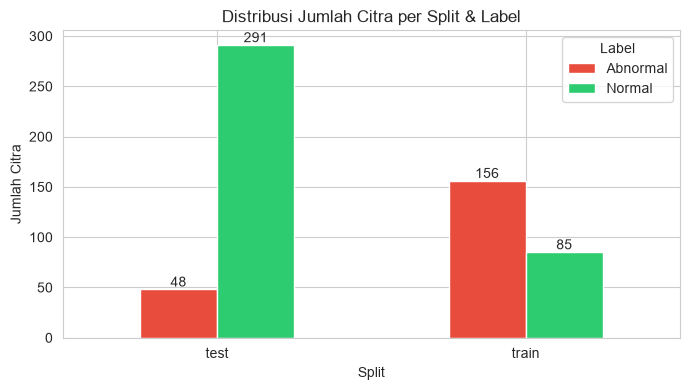

Total per label (train+test):
label
Normal      376
Abnormal    204
Name: count, dtype: int64

Rasio Abnormal:Normal = 204:376 (35.2% : 64.8%)


In [4]:
# --- Distribusi kelas per split ---
fig, ax = plt.subplots(figsize=(7, 4))
summary.plot(kind="bar", ax=ax, color=["#e74c3c", "#2ecc71"])
ax.set_title("Distribusi Jumlah Citra per Split & Label")
ax.set_xlabel("Split")
ax.set_ylabel("Jumlah Citra")
ax.legend(title="Label")
for container in ax.containers:
    ax.bar_label(container)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

label_counts = df["label"].value_counts()
print("Total per label (train+test):")
print(label_counts)
print(f"\nRasio Abnormal:Normal = {label_counts['Abnormal']}:{label_counts['Normal']}"
      f" ({label_counts['Abnormal']/len(df)*100:.1f}% : {label_counts['Normal']/len(df)*100:.1f}%)")

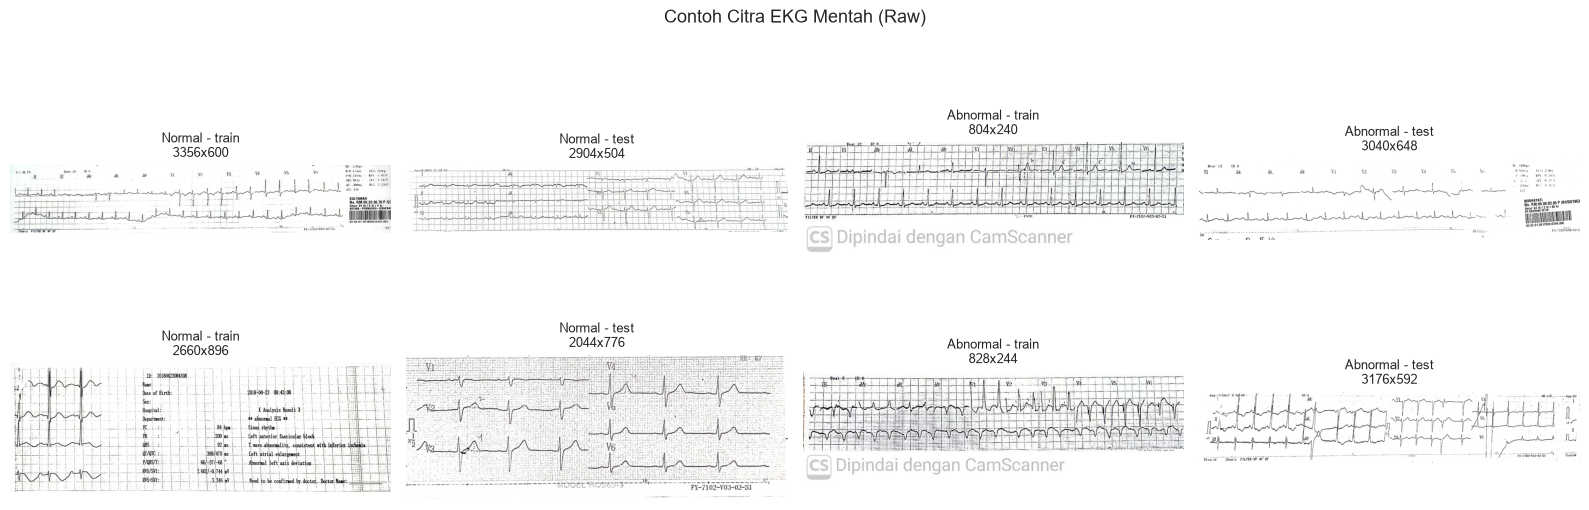

In [5]:
# --- Contoh citra mentah (raw) per kombinasi split/label ---
fig, axes = plt.subplots(2, 4, figsize=(16, 6))
combos = [("Normal", "train"), ("Normal", "test"), ("Abnormal", "train"), ("Abnormal", "test")]

for col, (label, split) in enumerate(combos):
    subset = df[(df["label"] == label) & (df["split"] == split)]
    samples = subset.sample(min(2, len(subset)), random_state=SEED)
    for row, (_, r) in enumerate(samples.iterrows()):
        img = cv2.cvtColor(cv2.imread(r["filepath"]), cv2.COLOR_BGR2RGB)
        axes[row, col].imshow(img)
        axes[row, col].set_title(f"{label} - {split}\n{img.shape[1]}x{img.shape[0]}", fontsize=9)
        axes[row, col].axis("off")

plt.suptitle("Contoh Citra EKG Mentah (Raw)", fontsize=13)
plt.tight_layout()
plt.show()

Reading dimensions:   0%|          | 0/580 [00:00<?, ?it/s]

Reading dimensions:  45%|████▌     | 263/580 [00:00<00:00, 2624.40it/s]

Reading dimensions:  91%|█████████ | 529/580 [00:00<00:00, 2643.54it/s]

Reading dimensions: 100%|██████████| 580/580 [00:00<00:00, 2622.66it/s]

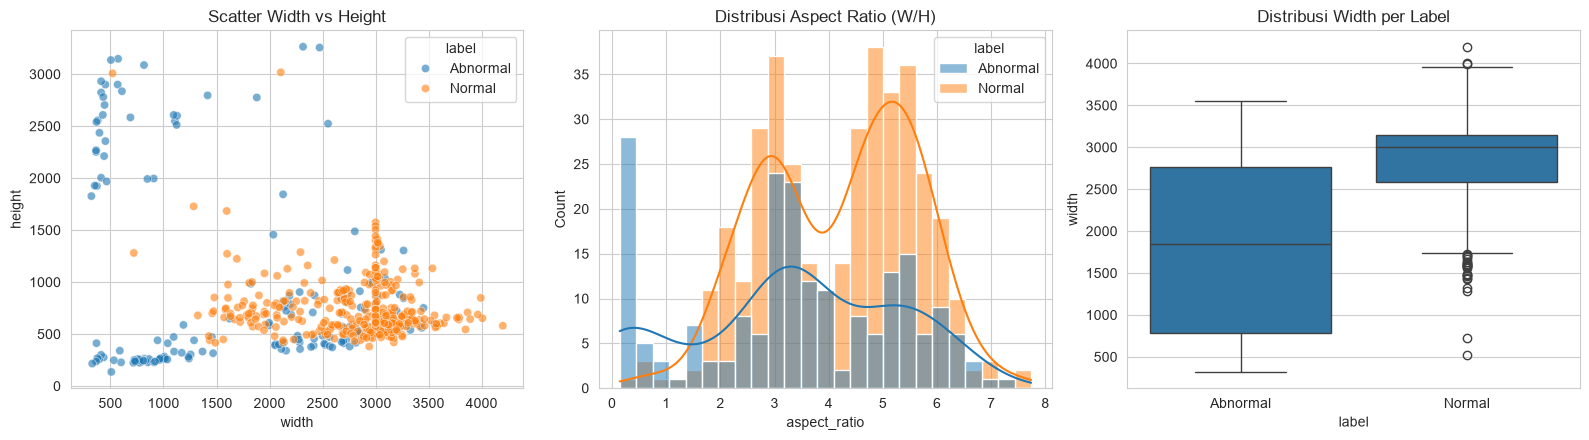

             width       height  aspect_ratio
count   580.000000   580.000000    580.000000
mean   2438.179310   778.844828      3.913856
std     914.218508   547.857920      1.652190
min     320.000000   136.000000      0.140518
25%    1948.000000   524.000000      2.894057
50%    2794.000000   630.000000      3.914981
75%    3088.000000   837.000000      5.263962
max    4200.000000  3264.000000      7.736842


In [6]:
# --- Distribusi ukuran gambar (width, height, aspect ratio) ---
from PIL import Image

dims = []
for _, r in tqdm(df.iterrows(), total=len(df), desc="Reading dimensions"):
    with Image.open(r["filepath"]) as im:
        w, h = im.size
    dims.append({"label": r["label"], "split": r["split"], "width": w, "height": h, "aspect_ratio": w / h})
dims_df = pd.DataFrame(dims)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

sns.scatterplot(data=dims_df, x="width", y="height", hue="label", alpha=0.6, ax=axes[0])
axes[0].set_title("Scatter Width vs Height")

sns.histplot(data=dims_df, x="aspect_ratio", hue="label", kde=True, ax=axes[1], bins=25)
axes[1].set_title("Distribusi Aspect Ratio (W/H)")

sns.boxplot(data=dims_df, x="label", y="width", ax=axes[2])
axes[2].set_title("Distribusi Width per Label")

plt.tight_layout()
plt.show()

print(dims_df[["width", "height", "aspect_ratio"]].describe())

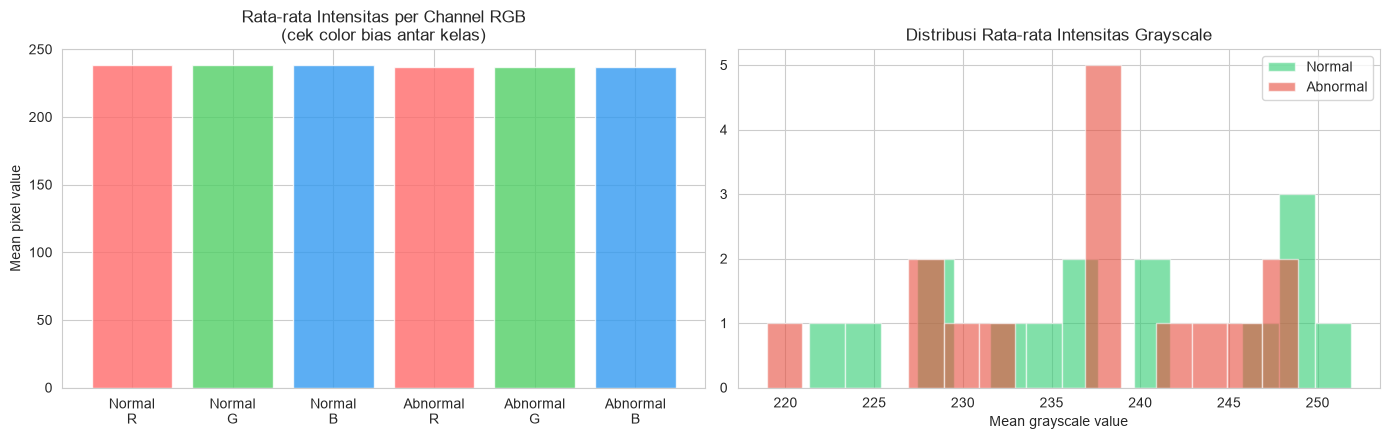

Catatan: jika mean R/G/B berbeda signifikan antar kelas, CNN bisa 'menyontek'
lewat warna alih-alih bentuk gelombang EKG -> alasan kita paksa grayscale (langkah preprocessing b).


In [7]:
# --- Distribusi intensitas piksel per channel RGB (cek color bias, ref. D-14) & grayscale ---
sample_df = pd.concat(
    [grp.sample(min(15, len(grp)), random_state=SEED) for _, grp in df.groupby("label")],
    ignore_index=True,
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
colors = {"Normal": "#2ecc71", "Abnormal": "#e74c3c"}

for label in ["Normal", "Abnormal"]:
    subset = sample_df[sample_df["label"] == label]
    r_vals, g_vals, b_vals, gray_vals = [], [], [], []
    for fp in subset["filepath"]:
        img_bgr = cv2.imread(fp)
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
        r_vals.append(img_rgb[:, :, 0].mean())
        g_vals.append(img_rgb[:, :, 1].mean())
        b_vals.append(img_rgb[:, :, 2].mean())
        gray_vals.append(gray.mean())
    axes[0].bar([f"{label}\nR", f"{label}\nG", f"{label}\nB"],
                [np.mean(r_vals), np.mean(g_vals), np.mean(b_vals)],
                color=["#ff6b6b", "#51cf66", "#339af0"], alpha=0.8)
    axes[1].hist(gray_vals, bins=15, alpha=0.6, label=label, color=colors[label])

axes[0].set_title("Rata-rata Intensitas per Channel RGB\n(cek color bias antar kelas)")
axes[0].set_ylabel("Mean pixel value")
axes[1].set_title("Distribusi Rata-rata Intensitas Grayscale")
axes[1].set_xlabel("Mean grayscale value")
axes[1].legend()
plt.tight_layout()
plt.show()

print("Catatan: jika mean R/G/B berbeda signifikan antar kelas, CNN bisa 'menyontek'")
print("lewat warna alih-alih bentuk gelombang EKG -> alasan kita paksa grayscale (langkah preprocessing b).")

## 3. Preprocessing Pipeline

Urutan sesuai spesifikasi:

a. **Load Image** — baca file & validasi
b. **Grayscale Conversion** — RGB → 1 channel (menghilangkan color bias, D-14)
c. **CLAHE** — clip limit 2.0, grid 8×8 (memperjelas gelombang EKG & mengurangi pengaruh grid latar belakang, D-13/D-15)
d. **Resize** — 224×224, interpolasi `INTER_AREA` (cocok untuk downscaling)
e. **Normalization** — ke rentang [0, 1], `float32`

In [8]:
TARGET_SIZE = (224, 224)   # (width, height)
CLAHE_CLIP_LIMIT = 2.0
CLAHE_TILE_GRID = (8, 8)


def load_image(filepath: str) -> np.ndarray:
    """a. Load Image: baca file & validasi, kembalikan array RGB uint8."""
    img_bgr = cv2.imread(filepath, cv2.IMREAD_COLOR)
    if img_bgr is None:
        raise ValueError(f"Gagal membaca gambar: {filepath}")
    return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)


def to_grayscale(img_rgb: np.ndarray) -> np.ndarray:
    """b. Grayscale Conversion: RGB -> 1 channel."""
    return cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)


def apply_clahe(gray_img: np.ndarray, clip_limit: float = CLAHE_CLIP_LIMIT,
                 tile_grid_size: tuple = CLAHE_TILE_GRID) -> np.ndarray:
    """c. CLAHE: clip 2.0, grid 8x8."""
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    return clahe.apply(gray_img)


def resize_image(img: np.ndarray, target_size: tuple = TARGET_SIZE) -> np.ndarray:
    """d. Resize: 224x224, INTER_AREA."""
    return cv2.resize(img, target_size, interpolation=cv2.INTER_AREA)


def normalize_image(img: np.ndarray) -> np.ndarray:
    """e. Normalization: [0, 1], float32."""
    return img.astype(np.float32) / 255.0


def preprocess_image(filepath: str, target_size: tuple = TARGET_SIZE,
                      clip_limit: float = CLAHE_CLIP_LIMIT,
                      tile_grid_size: tuple = CLAHE_TILE_GRID) -> np.ndarray:
    """Pipeline lengkap a->e. Mengembalikan array (H, W) float32 dalam [0, 1]."""
    rgb = load_image(filepath)
    gray = to_grayscale(rgb)
    enhanced = apply_clahe(gray, clip_limit, tile_grid_size)
    resized = resize_image(enhanced, target_size)
    normalized = normalize_image(resized)
    return normalized


print("Fungsi preprocessing siap: load_image -> to_grayscale -> apply_clahe -> resize_image -> normalize_image")

Fungsi preprocessing siap: load_image -> to_grayscale -> apply_clahe -> resize_image -> normalize_image


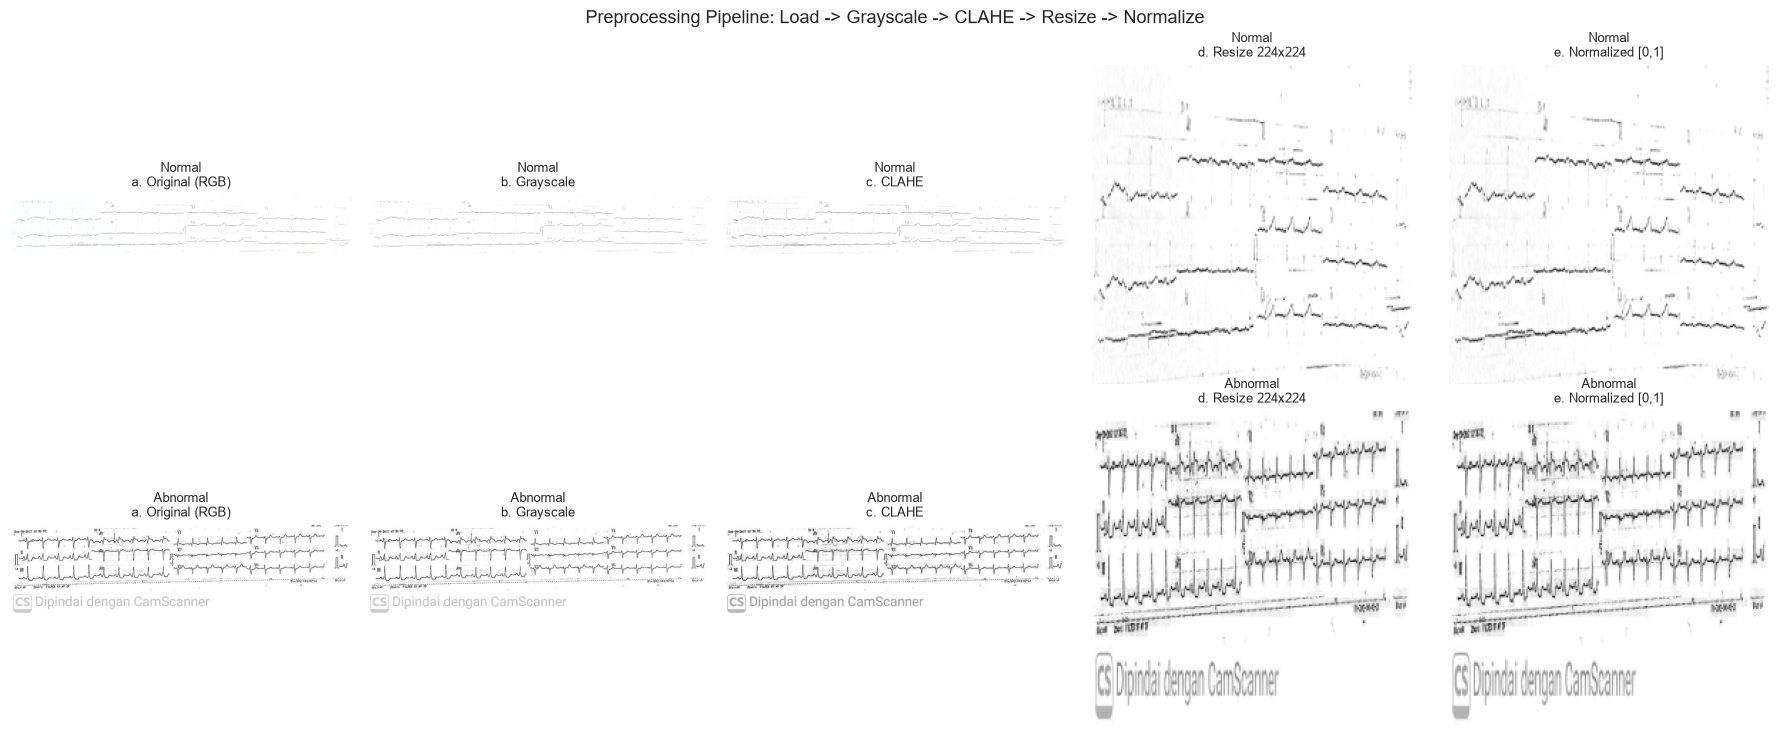

In [9]:
# --- Visualisasi setiap tahap pipeline pada 1 sample Normal & 1 sample Abnormal ---
step_names = ["a. Original (RGB)", "b. Grayscale", "c. CLAHE", "d. Resize 224x224", "e. Normalized [0,1]"]

fig, axes = plt.subplots(2, 5, figsize=(18, 7.5))

for row, label in enumerate(["Normal", "Abnormal"]):
    sample = df[df["label"] == label].sample(1, random_state=SEED).iloc[0]
    fp = sample["filepath"]

    rgb = load_image(fp)
    gray = to_grayscale(rgb)
    enhanced = apply_clahe(gray)
    resized = resize_image(enhanced)
    normalized = normalize_image(resized)

    steps = [rgb, gray, enhanced, resized, normalized]
    for col, (img, name) in enumerate(zip(steps, step_names)):
        cmap = None if col == 0 else "gray"
        axes[row, col].imshow(img, cmap=cmap)
        axes[row, col].set_title(f"{label}\n{name}", fontsize=9)
        axes[row, col].axis("off")

plt.suptitle("Preprocessing Pipeline: Load -> Grayscale -> CLAHE -> Resize -> Normalize", fontsize=13)
plt.tight_layout()
plt.show()

In [10]:
# --- Sanity check output preprocess_image() ---
sample_fp = df.iloc[0]["filepath"]
out = preprocess_image(sample_fp)
print("shape :", out.shape)
print("dtype :", out.dtype)
print("min   :", out.min())
print("max   :", out.max())
assert out.shape == (TARGET_SIZE[1], TARGET_SIZE[0])
assert out.dtype == np.float32
assert 0.0 <= out.min() and out.max() <= 1.0
print("\nOK - preprocess_image() sesuai spesifikasi (224x224, float32, [0,1]).")

shape : (224, 224)
dtype : float32
min   : 0.03529412
max   : 1.0

OK - preprocess_image() sesuai spesifikasi (224x224, float32, [0,1]).


## 4. Data Augmentation (Conservative)

Diterapkan **hanya pada data training**, setelah preprocessing (input berupa array `float32` [0,1] ukuran 224×224).

**Geometric (conservative, karena EKG sensitif terhadap distorsi):**
- Rotation ±5°
- Width shift ±5%
- Height shift ±5%
- Zoom ±5%

**Intensity:**
- Brightness [0.95, 1.05]
- Gaussian noise μ=0, σ=0.01
- Gaussian blur kernel=3, σ=[0.1, 0.5]

**Strategi class-specific:** kelas `Abnormal` (minoritas) mendapat augmentasi **1.5× lebih agresif** — parameter di atas dikalikan 1.5 (rotasi jadi ±7.5°, dst.) dan probabilitas penerapan tiap transformasi juga lebih tinggi, supaya persebaran variasi data minoritas lebih besar dibanding kelas `Normal`.

In [11]:
# --- Fungsi augmentasi individual (bekerja pada array float32 [0,1], shape (H, W)) ---

def random_rotate(img: np.ndarray, max_angle: float) -> np.ndarray:
    """Rotation +-max_angle derajat."""
    angle = np.random.uniform(-max_angle, max_angle)
    h, w = img.shape[:2]
    M = cv2.getRotationMatrix2D((w / 2, h / 2), angle, 1.0)
    return cv2.warpAffine(img, M, (w, h), borderMode=cv2.BORDER_REFLECT_101)


def random_shift(img: np.ndarray, max_shift_pct: float) -> np.ndarray:
    """Width & height shift +-max_shift_pct (fraksi lebar/tinggi)."""
    h, w = img.shape[:2]
    tx = np.random.uniform(-max_shift_pct, max_shift_pct) * w
    ty = np.random.uniform(-max_shift_pct, max_shift_pct) * h
    M = np.float32([[1, 0, tx], [0, 1, ty]])
    return cv2.warpAffine(img, M, (w, h), borderMode=cv2.BORDER_REFLECT_101)


def random_zoom(img: np.ndarray, max_zoom_pct: float) -> np.ndarray:
    """Zoom in/out +-max_zoom_pct."""
    h, w = img.shape[:2]
    zoom = 1.0 + np.random.uniform(-max_zoom_pct, max_zoom_pct)
    M = cv2.getRotationMatrix2D((w / 2, h / 2), 0, zoom)
    return cv2.warpAffine(img, M, (w, h), borderMode=cv2.BORDER_REFLECT_101)


def random_brightness(img: np.ndarray, brightness_range: tuple) -> np.ndarray:
    """Brightness scaling dalam brightness_range, hasil di-clip ke [0,1]."""
    factor = np.random.uniform(*brightness_range)
    return np.clip(img * factor, 0.0, 1.0).astype(np.float32)


def add_gaussian_noise(img: np.ndarray, mean: float, sigma: float) -> np.ndarray:
    """Gaussian noise mu=mean, sigma=sigma."""
    noise = np.random.normal(mean, sigma, img.shape).astype(np.float32)
    return np.clip(img + noise, 0.0, 1.0).astype(np.float32)


def random_gaussian_blur(img: np.ndarray, kernel_size: int, sigma_range: tuple) -> np.ndarray:
    """Gaussian blur, kernel tetap, sigma acak dalam sigma_range."""
    sigma = np.random.uniform(*sigma_range)
    return cv2.GaussianBlur(img, (kernel_size, kernel_size), sigma)


print("Fungsi augmentasi siap: random_rotate, random_shift, random_zoom,")
print("random_brightness, add_gaussian_noise, random_gaussian_blur")

Fungsi augmentasi siap: random_rotate, random_shift, random_zoom,
random_brightness, add_gaussian_noise, random_gaussian_blur


In [12]:
# --- Parameter dasar & multiplier class-specific ---
BASE_AUG_PARAMS = {
    "rotation_deg": 5.0,
    "shift_pct": 0.05,
    "zoom_pct": 0.05,
    "brightness_delta": 0.05,     # brightness_range = (1-delta, 1+delta) -> [0.95, 1.05]
    "noise_mean": 0.0,
    "noise_sigma": 0.01,
    "blur_kernel": 3,
    "blur_sigma_range": (0.1, 0.5),
    "apply_prob": 0.5,            # probabilitas tiap transformasi diterapkan
}

CLASS_AUG_MULTIPLIER = {
    "Normal": 1.0,     # augmentasi standar
    "Abnormal": 1.5,   # kelas minoritas -> 1.5x lebih agresif
}


def get_augmentation_params(label: str) -> dict:
    """Skala parameter augmentasi dasar sesuai multiplier kelas."""
    mult = CLASS_AUG_MULTIPLIER[label]
    return {
        "rotation_deg": BASE_AUG_PARAMS["rotation_deg"] * mult,
        "shift_pct": BASE_AUG_PARAMS["shift_pct"] * mult,
        "zoom_pct": BASE_AUG_PARAMS["zoom_pct"] * mult,
        "brightness_range": (
            max(0.0, 1 - BASE_AUG_PARAMS["brightness_delta"] * mult),
            1 + BASE_AUG_PARAMS["brightness_delta"] * mult,
        ),
        "noise_mean": BASE_AUG_PARAMS["noise_mean"],
        "noise_sigma": BASE_AUG_PARAMS["noise_sigma"] * mult,
        "blur_kernel": BASE_AUG_PARAMS["blur_kernel"],
        "blur_sigma_range": (
            BASE_AUG_PARAMS["blur_sigma_range"][0],
            BASE_AUG_PARAMS["blur_sigma_range"][1] * mult,
        ),
        "apply_prob": min(1.0, BASE_AUG_PARAMS["apply_prob"] * mult),
    }


def augment_image(img: np.ndarray, label: str) -> np.ndarray:
    """Terapkan augmentasi conservative, tiap transformasi punya peluang `apply_prob`
    untuk aktif, dengan kekuatan mengikuti strategi class-specific."""
    p = get_augmentation_params(label)
    out = img.copy()

    if np.random.rand() < p["apply_prob"]:
        out = random_rotate(out, p["rotation_deg"])
    if np.random.rand() < p["apply_prob"]:
        out = random_shift(out, p["shift_pct"])
    if np.random.rand() < p["apply_prob"]:
        out = random_zoom(out, p["zoom_pct"])
    if np.random.rand() < p["apply_prob"]:
        out = random_brightness(out, p["brightness_range"])
    if np.random.rand() < p["apply_prob"]:
        out = add_gaussian_noise(out, p["noise_mean"], p["noise_sigma"])
    if np.random.rand() < p["apply_prob"]:
        out = random_gaussian_blur(out, p["blur_kernel"], p["blur_sigma_range"])

    return out


print("Normal   params:", get_augmentation_params("Normal"))
print("Abnormal params:", get_augmentation_params("Abnormal"))

Normal   params: {'rotation_deg': 5.0, 'shift_pct': 0.05, 'zoom_pct': 0.05, 'brightness_range': (0.95, 1.05), 'noise_mean': 0.0, 'noise_sigma': 0.01, 'blur_kernel': 3, 'blur_sigma_range': (0.1, 0.5), 'apply_prob': 0.5}
Abnormal params: {'rotation_deg': 7.5, 'shift_pct': 0.07500000000000001, 'zoom_pct': 0.07500000000000001, 'brightness_range': (0.925, 1.075), 'noise_mean': 0.0, 'noise_sigma': 0.015, 'blur_kernel': 3, 'blur_sigma_range': (0.1, 0.75), 'apply_prob': 0.75}


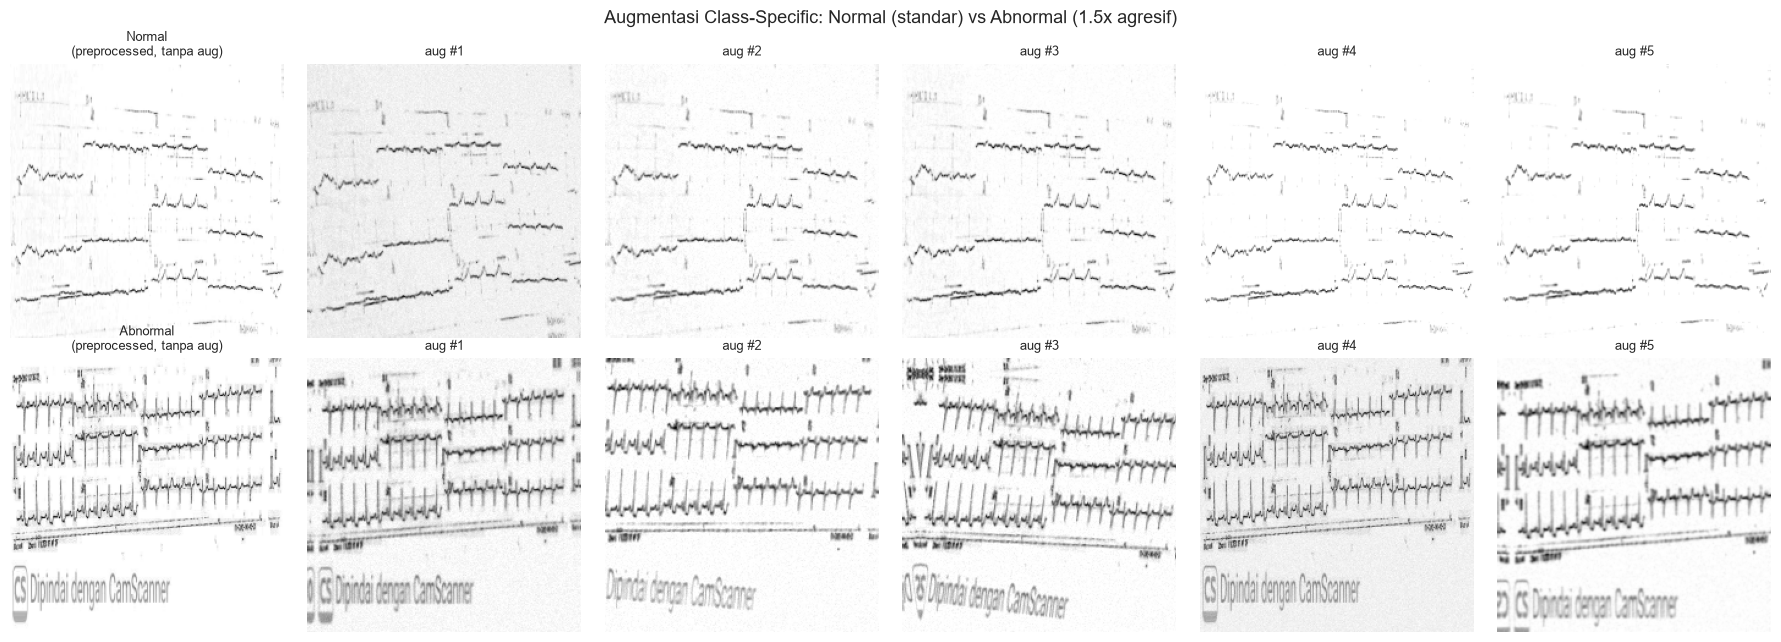

In [13]:
# --- Visualisasi hasil augmentasi: Normal (standar) vs Abnormal (1.5x agresif) ---
np.random.seed(SEED)
n_variants = 5

fig, axes = plt.subplots(2, n_variants + 1, figsize=(3 * (n_variants + 1), 6.5))

for row, label in enumerate(["Normal", "Abnormal"]):
    sample = df[df["label"] == label].sample(1, random_state=SEED).iloc[0]
    base_img = preprocess_image(sample["filepath"])

    axes[row, 0].imshow(base_img, cmap="gray")
    axes[row, 0].set_title(f"{label}\n(preprocessed, tanpa aug)", fontsize=9)
    axes[row, 0].axis("off")

    for v in range(n_variants):
        aug_img = augment_image(base_img, label)
        axes[row, v + 1].imshow(aug_img, cmap="gray")
        axes[row, v + 1].set_title(f"aug #{v + 1}", fontsize=9)
        axes[row, v + 1].axis("off")

plt.suptitle("Augmentasi Class-Specific: Normal (standar) vs Abnormal (1.5x agresif)", fontsize=13)
plt.tight_layout()
plt.show()

## 5. PyTorch Dataset & DataLoader

Membungkus seluruh pipeline (preprocessing + augmentasi khusus training) ke dalam `torch.utils.data.Dataset`, siap dipakai untuk tahap training CNN+Transformer selanjutnya.

In [14]:
LABEL_TO_IDX = {"Normal": 0, "Abnormal": 1}
IDX_TO_LABEL = {v: k for k, v in LABEL_TO_IDX.items()}


class EKGDataset(Dataset):
    """Dataset EKG: load -> grayscale -> CLAHE -> resize -> normalize -> (augment jika train)."""

    def __init__(self, dataframe: pd.DataFrame, augment: bool = False,
                 target_size: tuple = TARGET_SIZE,
                 clip_limit: float = CLAHE_CLIP_LIMIT,
                 tile_grid_size: tuple = CLAHE_TILE_GRID):
        self.df = dataframe.reset_index(drop=True)
        self.augment = augment
        self.target_size = target_size
        self.clip_limit = clip_limit
        self.tile_grid_size = tile_grid_size

    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, idx: int):
        row = self.df.iloc[idx]
        img = preprocess_image(row["filepath"], self.target_size, self.clip_limit, self.tile_grid_size)

        if self.augment:
            img = augment_image(img, row["label"])

        tensor = torch.from_numpy(img).unsqueeze(0).float()  # (1, H, W)
        label_idx = LABEL_TO_IDX[row["label"]]
        return tensor, label_idx


train_dataset = EKGDataset(df[df["split"] == "train"], augment=True)
test_dataset = EKGDataset(df[df["split"] == "test"], augment=False)

print(f"Train dataset: {len(train_dataset)} samples (augmentasi ON)")
print(f"Test dataset : {len(test_dataset)} samples (augmentasi OFF)")

BATCH_SIZE = 16
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

Train dataset: 241 samples (augmentasi ON)
Test dataset : 339 samples (augmentasi OFF)


Batch images shape: torch.Size([16, 1, 224, 224])
Batch labels shape: torch.Size([16])
dtype images: torch.float32 | dtype labels: torch.int64
min/max pixel value: 0.0010291878134012222 / 1.0
labels di batch ini: ['Abnormal', 'Normal', 'Abnormal', 'Abnormal', 'Abnormal', 'Abnormal', 'Abnormal', 'Abnormal', 'Abnormal', 'Normal', 'Normal', 'Normal', 'Abnormal', 'Abnormal', 'Abnormal', 'Normal']


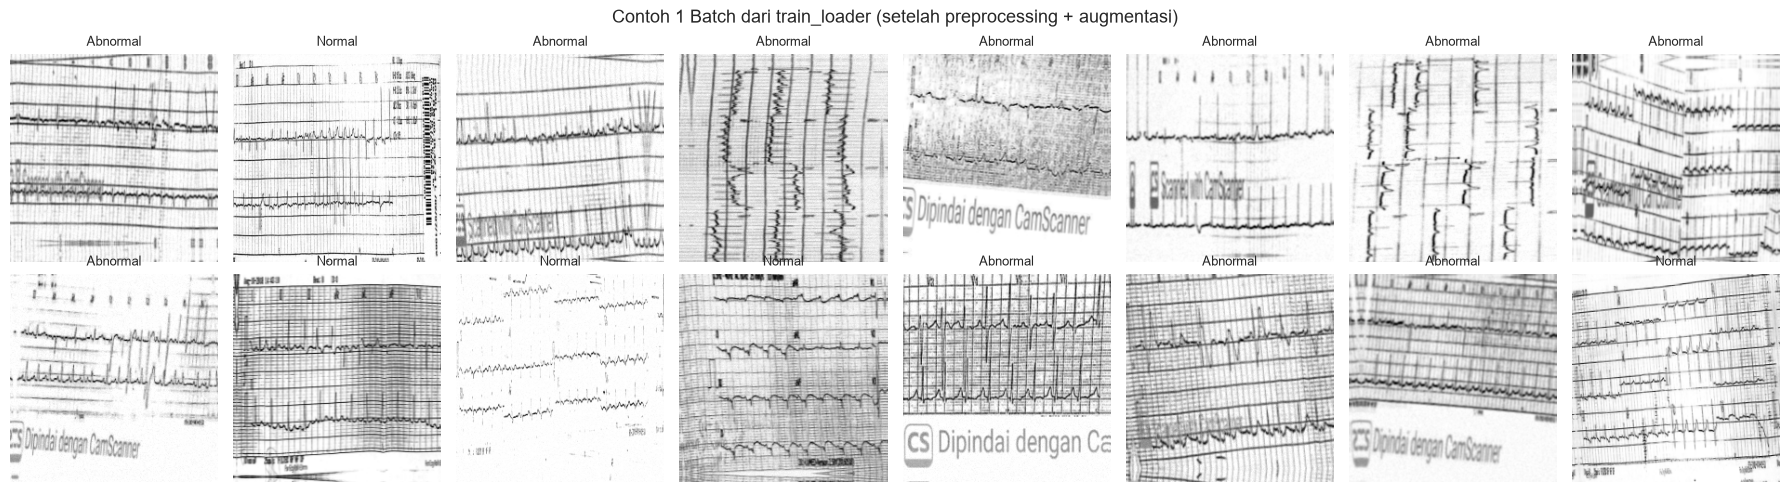

In [15]:
# --- Sanity check: ambil 1 batch dari train_loader ---
images, labels = next(iter(train_loader))
print("Batch images shape:", images.shape)   # (B, 1, 224, 224)
print("Batch labels shape:", labels.shape)
print("dtype images:", images.dtype, "| dtype labels:", labels.dtype)
print("min/max pixel value:", images.min().item(), "/", images.max().item())
print("labels di batch ini:", [IDX_TO_LABEL[i] for i in labels.tolist()])

fig, axes = plt.subplots(2, 8, figsize=(18, 5))
for i in range(min(16, images.shape[0])):
    ax = axes[i // 8, i % 8]
    ax.imshow(images[i, 0].numpy(), cmap="gray")
    ax.set_title(IDX_TO_LABEL[labels[i].item()], fontsize=9)
    ax.axis("off")
plt.suptitle("Contoh 1 Batch dari train_loader (setelah preprocessing + augmentasi)", fontsize=13)
plt.tight_layout()
plt.show()

## Ringkasan & Langkah Selanjutnya

Sampai sini sudah selesai:
- Load & validasi dataset (580 citra, 4 folder → `label` + `split`)
- EDA: distribusi kelas, contoh citra, distribusi ukuran, cek color bias
- Preprocessing: grayscale → CLAHE(2.0, 8×8) → resize 224×224 (INTER_AREA) → normalize [0,1] float32
- Augmentasi conservative (geometric + intensity), class-specific 1.5× untuk kelas Abnormal
- `EKGDataset` + `DataLoader` siap dipakai untuk training

**Langkah berikutnya (belum dikerjakan di notebook ini):** desain arsitektur hybrid CNN + Transformer, training loop, evaluasi metrik (accuracy/precision/recall/F1/AUC), dan penanganan ketidakseimbangan kelas lebih lanjut jika diperlukan (lihat catatan di bagian EDA soal rasio train/test yang tidak biasa pada kelas Normal).

---

# Bagian II — Modeling: CNN Baseline vs Hybrid CNN+Transformer

Keputusan yang sudah disepakati sebelumnya:
- **Gabungkan seluruh 580 citra** (folder train/test asli tidak dipakai lagi untuk modeling karena split-nya tidak seimbang), lalu evaluasi dengan **5-fold Stratified Cross-Validation** — setiap fold bergiliran jadi "test", tanpa perlu validation set terpisah.
- **Transfer learning**: backbone CNN memakai **ResNet18 pretrained ImageNet**, bukan dilatih dari nol (data terlalu kecil untuk itu).
- **Tidak ada hyperparameter tuning** — semua setting (epoch, learning rate, dsb) ditetapkan di awal dan dipakai apa adanya di semua fold & kedua model, supaya perbandingan CNN vs Hybrid adil.

## 6. Persiapan Data untuk Modeling

Langkah:
1. Precompute preprocessing (grayscale → CLAHE → resize → normalize) **sekali saja** untuk semua 580 gambar, di-cache di memori (menghindari pengulangan CLAHE yang mahal di setiap fold/epoch).
2. Saat training, cache ini diubah ke **3-channel** (duplikasi grayscale) + **normalisasi ImageNet** (mean/std khusus), karena backbone pretrained mengharapkan input seperti itu.
3. Siapkan **StratifiedKFold(n_splits=5)** dari seluruh data gabungan.

In [16]:
import torch.nn as nn
import torchvision.models as tvm
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report,
)

# --- 1. Precompute preprocessing sekali untuk semua gambar (cache di memori) ---
print(f"Precomputing preprocessing untuk {len(df)} gambar (grayscale->CLAHE->resize->normalize)...")
cached_images = np.zeros((len(df), TARGET_SIZE[1], TARGET_SIZE[0]), dtype=np.float32)
for i, fp in enumerate(tqdm(df["filepath"], desc="Caching preprocessed images")):
    cached_images[i] = preprocess_image(fp)

all_labels_arr = df["label"].values
print(f"Cache shape: {cached_images.shape}, dtype: {cached_images.dtype}")
print(f"Ukuran memori cache: {cached_images.nbytes / 1e6:.1f} MB")

# --- 2. Konstanta normalisasi ImageNet (dibutuhkan backbone pretrained) ---
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32).reshape(3, 1, 1)
IMAGENET_STD = np.array([0.229, 0.224, 0.225], dtype=np.float32).reshape(3, 1, 1)


class EKGModelDataset(Dataset):
    """Dataset untuk modeling: ambil dari cache (sudah preprocessed), augment jika train,
    lalu ubah ke 3-channel + normalisasi ImageNet."""

    def __init__(self, indices: np.ndarray, augment: bool = False):
        self.indices = indices
        self.augment = augment

    def __len__(self) -> int:
        return len(self.indices)

    def __getitem__(self, i: int):
        idx = self.indices[i]
        img = cached_images[idx]
        label_name = all_labels_arr[idx]

        if self.augment:
            img = augment_image(img, label_name)

        img_3ch = np.repeat(img[np.newaxis, :, :], 3, axis=0)          # (1,H,W) -> (3,H,W)
        img_3ch = (img_3ch - IMAGENET_MEAN) / IMAGENET_STD              # normalisasi ImageNet
        tensor = torch.from_numpy(img_3ch).float()
        label_idx = LABEL_TO_IDX[label_name]
        return tensor, label_idx


# --- 3. StratifiedKFold(5) dari seluruh data gabungan ---
N_SPLITS = 5
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

fold_indices = list(skf.split(np.zeros(len(df)), all_labels_arr))
for fold, (tr_idx, te_idx) in enumerate(fold_indices):
    tr_counts = pd.Series(all_labels_arr[tr_idx]).value_counts().to_dict()
    te_counts = pd.Series(all_labels_arr[te_idx]).value_counts().to_dict()
    print(f"Fold {fold+1}: train={len(tr_idx)} {tr_counts} | test={len(te_idx)} {te_counts}")

Precomputing preprocessing untuk 580 gambar (grayscale->CLAHE->resize->normalize)...


Caching preprocessed images:   0%|          | 0/580 [00:00<?, ?it/s]

Caching preprocessed images:   1%|          | 3/580 [00:00<00:20, 28.79it/s]

Caching preprocessed images:   1%|          | 6/580 [00:00<00:24, 23.36it/s]

Caching preprocessed images:   2%|▏         | 13/580 [00:00<00:14, 38.14it/s]

...

Caching preprocessed images:  98%|█████████▊| 569/580 [00:11<00:00, 43.24it/s]

Caching preprocessed images:  99%|█████████▉| 574/580 [00:11<00:00, 43.66it/s]

Caching preprocessed images: 100%|█████████▉| 579/580 [00:11<00:00, 42.31it/s]

Caching preprocessed images: 100%|██████████| 580/580 [00:11<00:00, 49.95it/s]

Cache shape: (580, 224, 224), dtype: float32
Ukuran memori cache: 116.4 MB
Fold 1: train=464 {'Normal': 301, 'Abnormal': 163} | test=116 {'Normal': 75, 'Abnormal': 41}
Fold 2: train=464 {'Normal': 301, 'Abnormal': 163} | test=116 {'Normal': 75, 'Abnormal': 41}
Fold 3: train=464 {'Normal': 301, 'Abnormal': 163} | test=116 {'Normal': 75, 'Abnormal': 41}
Fold 4: train=464 {'Normal': 301, 'Abnormal': 163} | test=116 {'Normal': 75, 'Abnormal': 41}
Fold 5: train=464 {'Normal': 300, 'Abnormal': 164} | test=116 {'Normal': 76, 'Abnormal': 40}


## 7. Model 1 — CNN Baseline (Transfer Learning)

ResNet18 pretrained ImageNet. Sebagian besar layer **dibekukan** (frozen) — hanya `layer4` (blok terakhir) dan `fc` (classifier head) yang dilatih. Ini strategi transfer learning standar untuk dataset kecil: memanfaatkan fitur umum dari ImageNet, hanya menyesuaikan fitur level-tinggi + keputusan akhir ke domain EKG.

In [17]:
def build_cnn_baseline(num_classes: int = 2) -> nn.Module:
    """ResNet18 pretrained, freeze semua layer kecuali layer4 & fc."""
    model = tvm.resnet18(weights=tvm.ResNet18_Weights.IMAGENET1K_V1)

    for param in model.parameters():
        param.requires_grad = False
    for param in model.layer4.parameters():
        param.requires_grad = True

    model.fc = nn.Linear(model.fc.in_features, num_classes)  # fc baru otomatis requires_grad=True
    return model


# Sanity check arsitektur
_tmp = build_cnn_baseline()
n_total = sum(p.numel() for p in _tmp.parameters())
n_trainable = sum(p.numel() for p in _tmp.parameters() if p.requires_grad)
print(f"CNN Baseline (ResNet18) - total params: {n_total:,} | trainable: {n_trainable:,} "
      f"({n_trainable/n_total*100:.1f}%)")
del _tmp

CNN Baseline (ResNet18) - total params: 11,177,538 | trainable: 8,394,754 (75.1%)


## 8. Model 2 — Hybrid CNN + Transformer

Arsitektur (sesuai diagram yang sudah didiskusikan):
1. **CNN backbone** (ResNet18 pretrained, tanpa `avgpool`/`fc`) → menghasilkan feature map `(B, 512, 7, 7)`.
2. **Tokenisasi** → feature map diratakan jadi 49 token @ 512-dim, ditambah 1 `[CLS]` token + positional embedding.
3. **Transformer Encoder** (2 layer, 8 attention head) → menangkap hubungan antar bagian sinyal EKG.
4. **Classifier head** dari output token `[CLS]`.

Backbone dibekukan sebagian (sama seperti CNN baseline) agar perbandingan adil — perbedaan utama antara kedua model murni terletak pada **ada/tidaknya Transformer**, bukan pada seberapa banyak CNN dilatih ulang.

In [18]:
class CNNTransformerHybrid(nn.Module):
    """ResNet18 backbone (feature extractor) -> tokens + [CLS] + positional embedding
    -> TransformerEncoder -> classifier head."""

    def __init__(self, num_classes: int = 2, num_transformer_layers: int = 2,
                 nhead: int = 8, dropout: float = 0.1):
        super().__init__()
        resnet = tvm.resnet18(weights=tvm.ResNet18_Weights.IMAGENET1K_V1)
        self.backbone = nn.Sequential(*list(resnet.children())[:-2])  # buang avgpool & fc -> (B,512,7,7)

        for param in self.backbone.parameters():
            param.requires_grad = False
        for param in self.backbone[-1].parameters():  # layer4 = child terakhir
            param.requires_grad = True

        d_model = 512
        num_patches = 7 * 7

        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, d_model))
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=d_model * 2,
            dropout=dropout, batch_first=True,
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_transformer_layers)
        self.norm = nn.LayerNorm(d_model)
        self.classifier = nn.Linear(d_model, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        feat = self.backbone(x)                              # (B, 512, 7, 7)
        B = feat.shape[0]
        tokens = feat.flatten(2).transpose(1, 2)              # (B, 49, 512)

        cls = self.cls_token.expand(B, -1, -1)                # (B, 1, 512)
        tokens = torch.cat([cls, tokens], dim=1)              # (B, 50, 512)
        tokens = tokens + self.pos_embed

        encoded = self.transformer(tokens)                   # (B, 50, 512)
        cls_out = self.norm(encoded[:, 0])                   # ambil [CLS]
        return self.classifier(cls_out)


# Sanity check arsitektur + forward pass dummy
_tmp = CNNTransformerHybrid()
n_total = sum(p.numel() for p in _tmp.parameters())
n_trainable = sum(p.numel() for p in _tmp.parameters() if p.requires_grad)
print(f"Hybrid CNN+Transformer - total params: {n_total:,} | trainable: {n_trainable:,} "
      f"({n_trainable/n_total*100:.1f}%)")

with torch.no_grad():
    dummy_out = _tmp(torch.randn(2, 3, 224, 224))
print("Output shape dummy forward pass:", dummy_out.shape)
del _tmp, dummy_out

Hybrid CNN+Transformer - total params: 15,410,242 | trainable: 12,627,458 (81.9%)
Output shape dummy forward pass: torch.Size([2, 2])


## 9. Training Loop + 5-Fold Cross-Validation

Setting dipakai **sama persis** untuk kedua model & semua fold (tidak ada tuning):
- Optimizer: Adam, learning rate `1e-4`
- Epoch: `12`
- Batch size: `16`
- Loss: `CrossEntropyLoss` dengan **class weight** (mengatasi imbalance Normal:Abnormal), dihitung ulang per fold dari data training fold tersebut saja (menghindari data leakage dari fold test).
- Augmentasi conservative class-specific (Bagian 4) tetap dipakai — hanya pada data training tiap fold.

In [19]:
# --- Hyperparameter tetap (fixed, tidak di-tuning) ---
EPOCHS = 12
LR = 1e-4
BATCH_SIZE_MODEL = 16


def train_one_fold(model: nn.Module, train_loader: DataLoader, test_loader: DataLoader,
                    class_weights: torch.Tensor, epochs: int = EPOCHS, lr: float = LR,
                    device: torch.device = DEVICE):
    """Latih 1 model pada 1 fold, kembalikan history per-epoch + prediksi akhir di test fold."""
    model = model.to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
    optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)

    history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}
    y_true, y_pred, y_prob = None, None, None

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * imgs.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)
        history["train_loss"].append(running_loss / total)
        history["train_acc"].append(correct / total)

        model.eval()
        running_loss, correct, total = 0.0, 0, 0
        epoch_true, epoch_pred, epoch_prob = [], [], []
        with torch.no_grad():
            for imgs, labels in test_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)

                running_loss += loss.item() * imgs.size(0)
                preds = outputs.argmax(1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)

                probs = torch.softmax(outputs, dim=1)[:, 1]
                epoch_true.extend(labels.cpu().numpy())
                epoch_pred.extend(preds.cpu().numpy())
                epoch_prob.extend(probs.cpu().numpy())
        history["test_loss"].append(running_loss / total)
        history["test_acc"].append(correct / total)
        y_true, y_pred, y_prob = np.array(epoch_true), np.array(epoch_pred), np.array(epoch_prob)

    return history, y_true, y_pred, y_prob


def compute_class_weights(train_labels: np.ndarray) -> torch.Tensor:
    """Class weight inverse-frequency, dihitung dari label training fold saja."""
    classes, counts = np.unique(train_labels, return_counts=True)
    weight_map = {c: len(train_labels) / (len(classes) * cnt) for c, cnt in zip(classes, counts)}
    return torch.tensor([weight_map["Normal"], weight_map["Abnormal"]], dtype=torch.float32)


def run_cross_validation(model_builder, model_name: str):
    """Jalankan 5-fold CV untuk 1 model, kembalikan metrik & prediksi tiap fold."""
    fold_metrics, fold_histories = [], []
    labels_cv, preds_cv, probs_cv = [], [], []

    for fold, (train_idx, test_idx) in enumerate(fold_indices):
        print(f"\n=== {model_name} | Fold {fold + 1}/{N_SPLITS} ===")
        torch.manual_seed(SEED + fold)

        class_weights = compute_class_weights(all_labels_arr[train_idx])

        train_loader_fold = DataLoader(
            EKGModelDataset(train_idx, augment=True),
            batch_size=BATCH_SIZE_MODEL, shuffle=True, num_workers=0,
        )
        test_loader_fold = DataLoader(
            EKGModelDataset(test_idx, augment=False),
            batch_size=BATCH_SIZE_MODEL, shuffle=False, num_workers=0,
        )

        model = model_builder()
        history, y_true, y_pred, y_prob = train_one_fold(model, train_loader_fold, test_loader_fold, class_weights)

        fold_histories.append(history)
        labels_cv.append(y_true)
        preds_cv.append(y_pred)
        probs_cv.append(y_prob)

        acc = accuracy_score(y_true, y_pred)
        prec = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
        rec = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
        f1 = f1_score(y_true, y_pred, pos_label=1, zero_division=0)
        auc = roc_auc_score(y_true, y_prob)
        fold_metrics.append({"fold": fold + 1, "accuracy": acc, "precision": prec,
                              "recall": rec, "f1": f1, "auc": auc})
        print(f"  acc={acc:.3f}  precision={prec:.3f}  recall={rec:.3f}  f1={f1:.3f}  auc={auc:.3f}")

        del model
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    return pd.DataFrame(fold_metrics), fold_histories, labels_cv, preds_cv, probs_cv


print("Fungsi training & 5-fold CV siap dijalankan.")

Fungsi training & 5-fold CV siap dijalankan.


In [20]:
import time

t0 = time.time()
cnn_metrics_df, cnn_histories, cnn_labels_cv, cnn_preds_cv, cnn_probs_cv = run_cross_validation(
    build_cnn_baseline, "CNN Baseline"
)
print(f"\nCNN Baseline selesai dalam {time.time()-t0:.1f} detik")
cnn_metrics_df


=== CNN Baseline | Fold 1/5 ===


  acc=0.828  precision=0.957  recall=0.537  f1=0.688  auc=0.878

=== CNN Baseline | Fold 2/5 ===


  acc=0.810  precision=0.952  recall=0.488  f1=0.645  auc=0.824

=== CNN Baseline | Fold 3/5 ===


  acc=0.879  precision=0.966  recall=0.683  f1=0.800  auc=0.882

=== CNN Baseline | Fold 4/5 ===


  acc=0.862  precision=0.903  recall=0.683  f1=0.778  auc=0.903

=== CNN Baseline | Fold 5/5 ===


  acc=0.828  precision=1.000  recall=0.500  f1=0.667  auc=0.861

CNN Baseline selesai dalam 98.1 detik


,fold,accuracy,precision,recall,f1,auc
0,1,0.827586,0.956522,0.536585,0.687500,0.878374
1,2,0.810345,0.952381,0.487805,0.645161,0.823740
2,3,0.879310,0.965517,0.682927,0.800000,0.882276
3,4,0.862069,0.903226,0.682927,0.777778,0.903415
4,5,0.827586,1.000000,0.500000,0.666667,0.860855


In [21]:
t0 = time.time()
hybrid_metrics_df, hybrid_histories, hybrid_labels_cv, hybrid_preds_cv, hybrid_probs_cv = run_cross_validation(
    lambda: CNNTransformerHybrid(), "CNN+Transformer Hybrid"
)
print(f"\nHybrid CNN+Transformer selesai dalam {time.time()-t0:.1f} detik")
hybrid_metrics_df


=== CNN+Transformer Hybrid | Fold 1/5 ===


  acc=0.871  precision=0.964  recall=0.659  f1=0.783  auc=0.918

=== CNN+Transformer Hybrid | Fold 2/5 ===


  acc=0.802  precision=0.800  recall=0.585  f1=0.676  auc=0.855

=== CNN+Transformer Hybrid | Fold 3/5 ===


  acc=0.853  precision=0.900  recall=0.659  f1=0.761  auc=0.856

=== CNN+Transformer Hybrid | Fold 4/5 ===


  acc=0.879  precision=0.886  recall=0.756  f1=0.816  auc=0.945

=== CNN+Transformer Hybrid | Fold 5/5 ===


  acc=0.819  precision=0.913  recall=0.525  f1=0.667  auc=0.893

Hybrid CNN+Transformer selesai dalam 115.9 detik


,fold,accuracy,precision,recall,f1,auc
0,1,0.870690,0.964286,0.658537,0.782609,0.918049
1,2,0.801724,0.800000,0.585366,0.676056,0.855285
2,3,0.853448,0.900000,0.658537,0.760563,0.855935
3,4,0.879310,0.885714,0.756098,0.815789,0.944715
4,5,0.818966,0.913043,0.525000,0.666667,0.893421


## 10. Evaluasi & Visualisasi Hasil

Metrik yang dilaporkan (per fold, lalu dirata-rata ± std dari 5 fold):
- **Accuracy** — proporsi prediksi benar keseluruhan.
- **Precision** (kelas Abnormal) — dari semua yang diprediksi Abnormal, berapa % benar-benar Abnormal.
- **Recall / Sensitivity** (kelas Abnormal) — dari semua yang benar-benar Abnormal, berapa % berhasil terdeteksi. **Metrik paling kritis** untuk kasus medis (jangan sampai pasien Abnormal terlewat).
- **F1-score** — harmonic mean precision & recall.
- **AUC-ROC** — kemampuan model memisahkan kedua kelas di semua threshold.
- **Confusion Matrix** — rincian benar/salah per kelas.

In [22]:
# --- Tabel ringkasan metrik: mean +- std dari 5 fold, untuk kedua model ---
METRIC_COLS = ["accuracy", "precision", "recall", "f1", "auc"]

def summarize_metrics(metrics_df: pd.DataFrame, model_name: str) -> pd.Series:
    summary = {}
    for col in METRIC_COLS:
        summary[f"{col}_mean"] = metrics_df[col].mean()
        summary[f"{col}_std"] = metrics_df[col].std()
    return pd.Series(summary, name=model_name)

comparison_df = pd.DataFrame([
    summarize_metrics(cnn_metrics_df, "CNN Baseline"),
    summarize_metrics(hybrid_metrics_df, "CNN+Transformer Hybrid"),
])

print("=== Hasil per-fold: CNN Baseline ===")
print(cnn_metrics_df.to_string(index=False))
print("\n=== Hasil per-fold: CNN+Transformer Hybrid ===")
print(hybrid_metrics_df.to_string(index=False))
print("\n=== Ringkasan (mean +- std, 5-fold) ===")
comparison_df

=== Hasil per-fold: CNN Baseline ===
 fold  accuracy  precision   recall       f1      auc
    1  0.827586   0.956522 0.536585 0.687500 0.878374
    2  0.810345   0.952381 0.487805 0.645161 0.823740
    3  0.879310   0.965517 0.682927 0.800000 0.882276
    4  0.862069   0.903226 0.682927 0.777778 0.903415
    5  0.827586   1.000000 0.500000 0.666667 0.860855

=== Hasil per-fold: CNN+Transformer Hybrid ===
 fold  accuracy  precision   recall       f1      auc
    1  0.870690   0.964286 0.658537 0.782609 0.918049
    2  0.801724   0.800000 0.585366 0.676056 0.855285
    3  0.853448   0.900000 0.658537 0.760563 0.855935
    4  0.879310   0.885714 0.756098 0.815789 0.944715
    5  0.818966   0.913043 0.525000 0.666667 0.893421

=== Ringkasan (mean +- std, 5-fold) ===


,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,auc_mean,auc_std
CNN Baseline,0.841379,0.028330,0.955529,0.034727,0.578049,0.097408,0.715421,0.069165,0.869732,0.029836
CNN+Transformer Hybrid,0.844828,0.033388,0.892609,0.059653,0.636707,0.087065,0.740337,0.066046,0.893481,0.039042


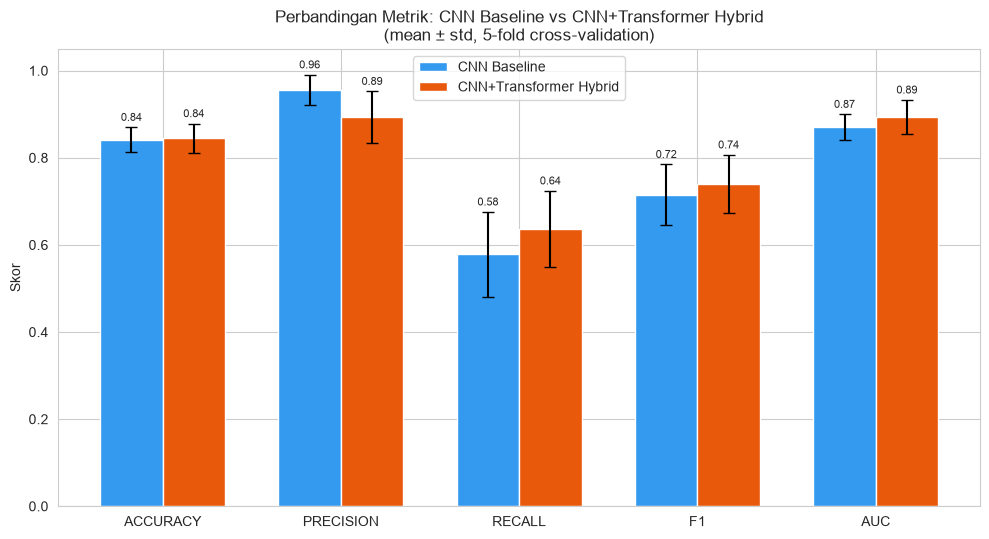

In [23]:
# --- Grafik 1: Bar chart perbandingan metrik (mean +- std) CNN vs Hybrid ---
x = np.arange(len(METRIC_COLS))
width = 0.35

cnn_means = [comparison_df.loc["CNN Baseline", f"{c}_mean"] for c in METRIC_COLS]
cnn_stds = [comparison_df.loc["CNN Baseline", f"{c}_std"] for c in METRIC_COLS]
hybrid_means = [comparison_df.loc["CNN+Transformer Hybrid", f"{c}_mean"] for c in METRIC_COLS]
hybrid_stds = [comparison_df.loc["CNN+Transformer Hybrid", f"{c}_std"] for c in METRIC_COLS]

fig, ax = plt.subplots(figsize=(10, 5.5))
b1 = ax.bar(x - width/2, cnn_means, width, yerr=cnn_stds, capsize=4, label="CNN Baseline", color="#339af0")
b2 = ax.bar(x + width/2, hybrid_means, width, yerr=hybrid_stds, capsize=4, label="CNN+Transformer Hybrid", color="#e8590c")

ax.set_xticks(x)
ax.set_xticklabels([c.upper() for c in METRIC_COLS])
ax.set_ylim(0, 1.05)
ax.set_ylabel("Skor")
ax.set_title("Perbandingan Metrik: CNN Baseline vs CNN+Transformer Hybrid\n(mean ± std, 5-fold cross-validation)")
ax.legend()
ax.bar_label(b1, fmt="%.2f", padding=3, fontsize=8)
ax.bar_label(b2, fmt="%.2f", padding=3, fontsize=8)
plt.tight_layout()
plt.show()

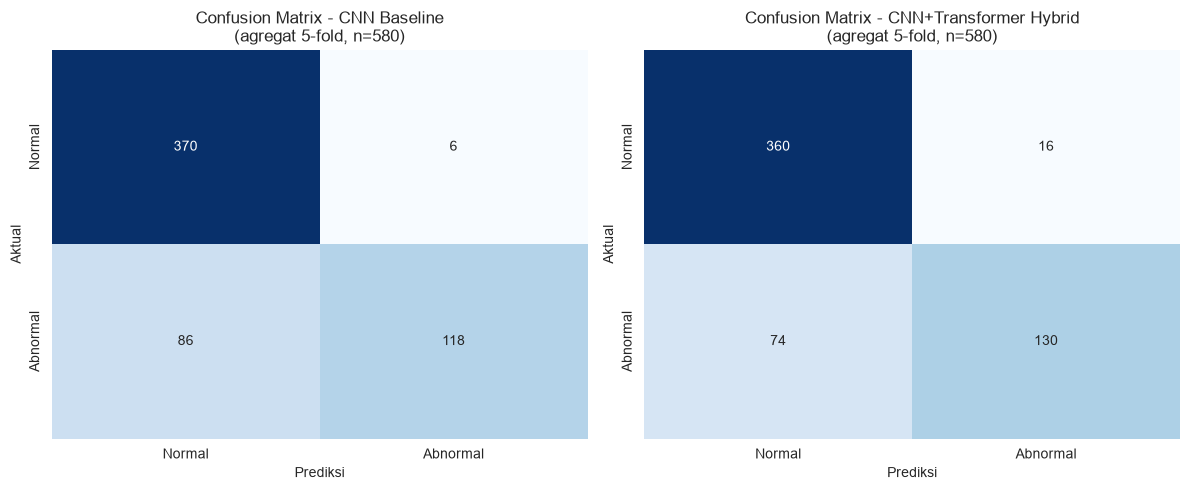

=== Classification Report: CNN Baseline ===
              precision    recall  f1-score   support

      Normal       0.81      0.98      0.89       376
    Abnormal       0.95      0.58      0.72       204

    accuracy                           0.84       580
   macro avg       0.88      0.78      0.80       580
weighted avg       0.86      0.84      0.83       580

=== Classification Report: CNN+Transformer Hybrid ===
              precision    recall  f1-score   support

      Normal       0.83      0.96      0.89       376
    Abnormal       0.89      0.64      0.74       204

    accuracy                           0.84       580
   macro avg       0.86      0.80      0.82       580
weighted avg       0.85      0.84      0.84       580



In [24]:
# --- Grafik 2: Confusion Matrix (agregat seluruh fold = seluruh 580 data, tiap data diprediksi tepat 1x sbg test) ---
cnn_all_true = np.concatenate(cnn_labels_cv)
cnn_all_pred = np.concatenate(cnn_preds_cv)
hybrid_all_true = np.concatenate(hybrid_labels_cv)
hybrid_all_pred = np.concatenate(hybrid_preds_cv)

cm_cnn = confusion_matrix(cnn_all_true, cnn_all_pred)
cm_hybrid = confusion_matrix(hybrid_all_true, hybrid_all_pred)

class_names = [IDX_TO_LABEL[0], IDX_TO_LABEL[1]]  # ["Normal", "Abnormal"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, cm, title in zip(axes, [cm_cnn, cm_hybrid], ["CNN Baseline", "CNN+Transformer Hybrid"]):
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_xlabel("Prediksi")
    ax.set_ylabel("Aktual")
    ax.set_title(f"Confusion Matrix - {title}\n(agregat 5-fold, n={cm.sum()})")

plt.tight_layout()
plt.show()

print("=== Classification Report: CNN Baseline ===")
print(classification_report(cnn_all_true, cnn_all_pred, target_names=class_names, zero_division=0))
print("=== Classification Report: CNN+Transformer Hybrid ===")
print(classification_report(hybrid_all_true, hybrid_all_pred, target_names=class_names, zero_division=0))

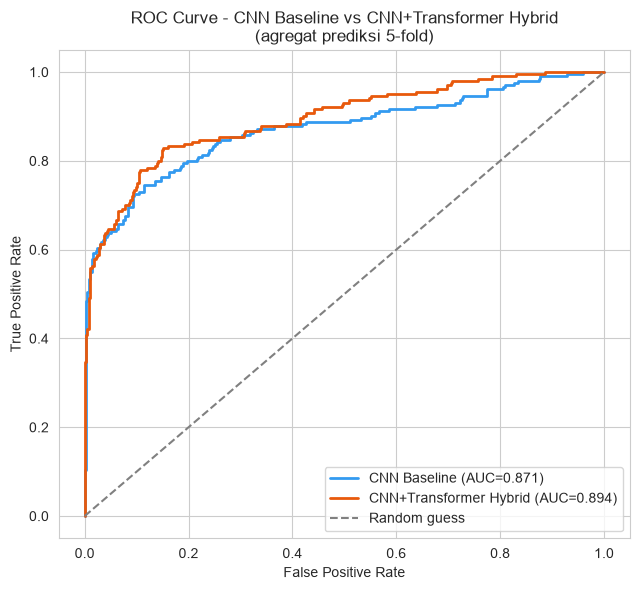

In [25]:
# --- Grafik 3: ROC Curve (agregat prediksi seluruh fold) ---
cnn_all_prob = np.concatenate(cnn_probs_cv)
hybrid_all_prob = np.concatenate(hybrid_probs_cv)

fpr_cnn, tpr_cnn, _ = roc_curve(cnn_all_true, cnn_all_prob)
fpr_hybrid, tpr_hybrid, _ = roc_curve(hybrid_all_true, hybrid_all_prob)
auc_cnn = roc_auc_score(cnn_all_true, cnn_all_prob)
auc_hybrid = roc_auc_score(hybrid_all_true, hybrid_all_prob)

fig, ax = plt.subplots(figsize=(6.5, 6))
ax.plot(fpr_cnn, tpr_cnn, label=f"CNN Baseline (AUC={auc_cnn:.3f})", color="#339af0", linewidth=2)
ax.plot(fpr_hybrid, tpr_hybrid, label=f"CNN+Transformer Hybrid (AUC={auc_hybrid:.3f})", color="#e8590c", linewidth=2)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve - CNN Baseline vs CNN+Transformer Hybrid\n(agregat prediksi 5-fold)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

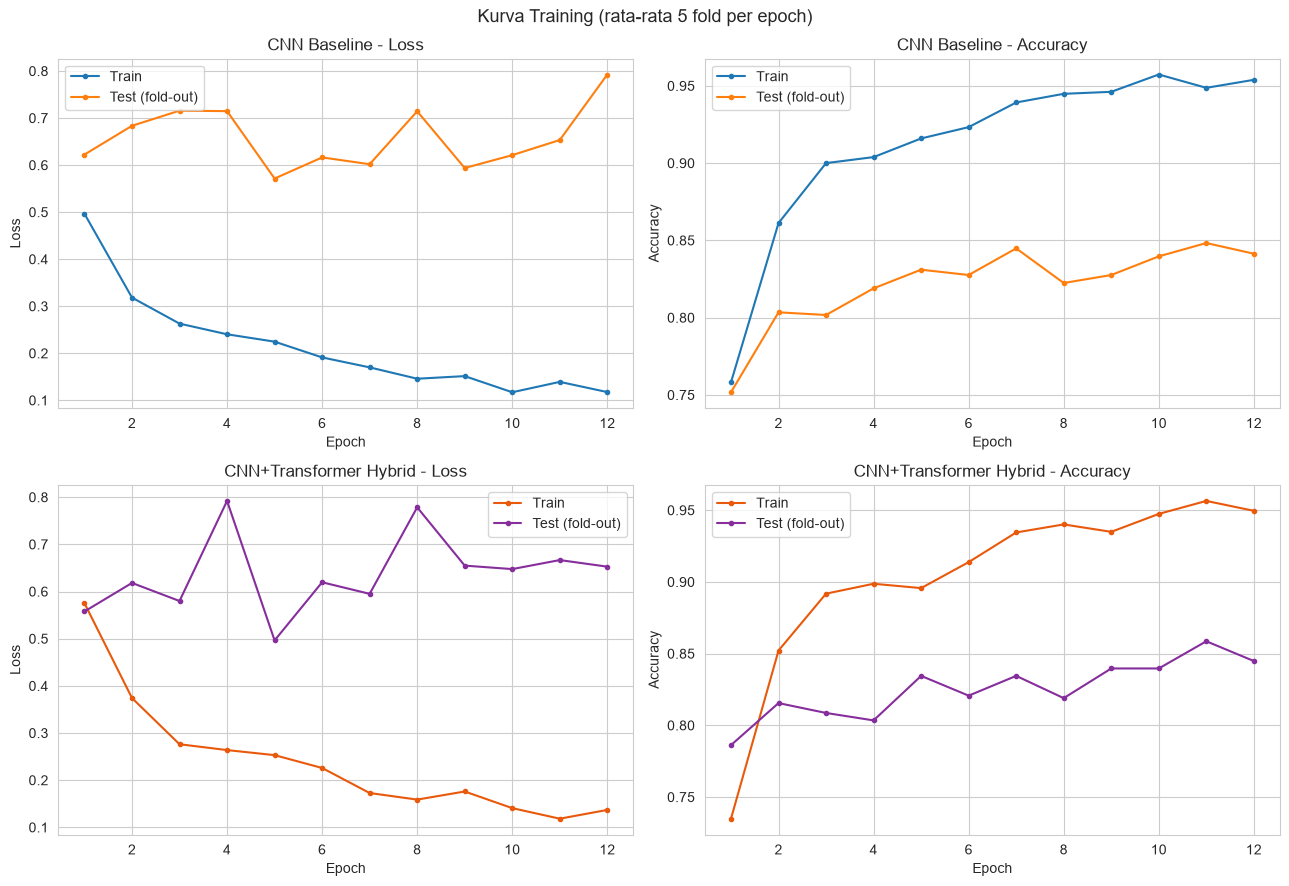

In [26]:
# --- Grafik 4: Training curves (loss & accuracy, dirata-rata antar 5 fold per epoch) ---
def average_history(histories: list) -> dict:
    keys = histories[0].keys()
    return {k: np.mean([h[k] for h in histories], axis=0) for k in keys}

cnn_avg_hist = average_history(cnn_histories)
hybrid_avg_hist = average_history(hybrid_histories)
epochs_range = np.arange(1, EPOCHS + 1)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

axes[0, 0].plot(epochs_range, cnn_avg_hist["train_loss"], label="Train", marker="o", markersize=3)
axes[0, 0].plot(epochs_range, cnn_avg_hist["test_loss"], label="Test (fold-out)", marker="o", markersize=3)
axes[0, 0].set_title("CNN Baseline - Loss")
axes[0, 0].set_xlabel("Epoch"); axes[0, 0].set_ylabel("Loss"); axes[0, 0].legend()

axes[0, 1].plot(epochs_range, cnn_avg_hist["train_acc"], label="Train", marker="o", markersize=3)
axes[0, 1].plot(epochs_range, cnn_avg_hist["test_acc"], label="Test (fold-out)", marker="o", markersize=3)
axes[0, 1].set_title("CNN Baseline - Accuracy")
axes[0, 1].set_xlabel("Epoch"); axes[0, 1].set_ylabel("Accuracy"); axes[0, 1].legend()

axes[1, 0].plot(epochs_range, hybrid_avg_hist["train_loss"], label="Train", marker="o", markersize=3, color="#e8590c")
axes[1, 0].plot(epochs_range, hybrid_avg_hist["test_loss"], label="Test (fold-out)", marker="o", markersize=3, color="#862e9c")
axes[1, 0].set_title("CNN+Transformer Hybrid - Loss")
axes[1, 0].set_xlabel("Epoch"); axes[1, 0].set_ylabel("Loss"); axes[1, 0].legend()

axes[1, 1].plot(epochs_range, hybrid_avg_hist["train_acc"], label="Train", marker="o", markersize=3, color="#e8590c")
axes[1, 1].plot(epochs_range, hybrid_avg_hist["test_acc"], label="Test (fold-out)", marker="o", markersize=3, color="#862e9c")
axes[1, 1].set_title("CNN+Transformer Hybrid - Accuracy")
axes[1, 1].set_xlabel("Epoch"); axes[1, 1].set_ylabel("Accuracy"); axes[1, 1].legend()

plt.suptitle("Kurva Training (rata-rata 5 fold per epoch)", fontsize=13)
plt.tight_layout()
plt.show()

In [27]:
# --- Kesimpulan otomatis berdasarkan hasil aktual di atas (bukan teks statis) ---
def fmt(v):
    return f"{v:.3f}"

better_acc = "CNN+Transformer Hybrid" if comparison_df.loc["CNN+Transformer Hybrid", "accuracy_mean"] > comparison_df.loc["CNN Baseline", "accuracy_mean"] else "CNN Baseline"
better_recall = "CNN+Transformer Hybrid" if comparison_df.loc["CNN+Transformer Hybrid", "recall_mean"] > comparison_df.loc["CNN Baseline", "recall_mean"] else "CNN Baseline"
better_auc = "CNN+Transformer Hybrid" if comparison_df.loc["CNN+Transformer Hybrid", "auc_mean"] > comparison_df.loc["CNN Baseline", "auc_mean"] else "CNN Baseline"

cnn_gap = cnn_avg_hist["train_acc"][-1] - cnn_avg_hist["test_acc"][-1]
hybrid_gap = hybrid_avg_hist["train_acc"][-1] - hybrid_avg_hist["test_acc"][-1]

print("=" * 70)
print("KESIMPULAN OTOMATIS (berdasarkan hasil run di atas)")
print("=" * 70)
print(f"\n1. Accuracy rata-rata lebih tinggi  : {better_acc}")
print(f"   CNN Baseline   : {fmt(comparison_df.loc['CNN Baseline','accuracy_mean'])} +- {fmt(comparison_df.loc['CNN Baseline','accuracy_std'])}")
print(f"   Hybrid         : {fmt(comparison_df.loc['CNN+Transformer Hybrid','accuracy_mean'])} +- {fmt(comparison_df.loc['CNN+Transformer Hybrid','accuracy_std'])}")

print(f"\n2. Recall kelas Abnormal (paling kritis di kasus medis) lebih tinggi: {better_recall}")
print(f"   CNN Baseline   : {fmt(comparison_df.loc['CNN Baseline','recall_mean'])} +- {fmt(comparison_df.loc['CNN Baseline','recall_std'])}")
print(f"   Hybrid         : {fmt(comparison_df.loc['CNN+Transformer Hybrid','recall_mean'])} +- {fmt(comparison_df.loc['CNN+Transformer Hybrid','recall_std'])}")

print(f"\n3. AUC-ROC lebih tinggi             : {better_auc}")
print(f"   CNN Baseline   : {fmt(comparison_df.loc['CNN Baseline','auc_mean'])}")
print(f"   Hybrid         : {fmt(comparison_df.loc['CNN+Transformer Hybrid','auc_mean'])}")

print(f"\n4. Gap train-test accuracy (indikasi overfitting, epoch terakhir):")
print(f"   CNN Baseline   : {fmt(cnn_gap)}  {'<- gap besar, waspada overfitting' if cnn_gap > 0.15 else ''}")
print(f"   Hybrid         : {fmt(hybrid_gap)}  {'<- gap besar, waspada overfitting' if hybrid_gap > 0.15 else ''}")

print("\n" + "=" * 70)
print("SARAN (tanpa tuning, berdasarkan hasil ini)")
print("=" * 70)
print("""
- Jika Hybrid TIDAK mengungguli CNN Baseline secara meyakinkan: ini wajar untuk
  dataset sekecil ini (580 citra). Transformer butuh data lebih banyak untuk
  menunjukkan keunggulannya menangkap hubungan global antar bagian sinyal.
- Jika gap train-test accuracy besar pada salah satu model: model overfit ke data
  training. Opsi ke depan (bukan bagian scope saat ini): tambah data, regularisasi
  (dropout lebih besar / weight decay), atau augmentasi lebih agresif.
- Perhatikan recall Abnormal secara khusus: accuracy tinggi bisa menipu jika model
  cenderung menebak Normal (kelas mayoritas). Confusion matrix di atas menunjukkan
  rincian kesalahan tiap kelas.
- Untuk kesimpulan yang lebih kuat secara statistik, idealnya perbedaan CNN vs
  Hybrid diuji dengan uji signifikansi (mis. paired t-test antar fold) -- belum
  dilakukan di sini karena di luar scope saat ini.
""")

KESIMPULAN OTOMATIS (berdasarkan hasil run di atas)

1. Accuracy rata-rata lebih tinggi  : CNN+Transformer Hybrid
   CNN Baseline   : 0.841 +- 0.028
   Hybrid         : 0.845 +- 0.033

2. Recall kelas Abnormal (paling kritis di kasus medis) lebih tinggi: CNN+Transformer Hybrid
   CNN Baseline   : 0.578 +- 0.097
   Hybrid         : 0.637 +- 0.087

3. AUC-ROC lebih tinggi             : CNN+Transformer Hybrid
   CNN Baseline   : 0.870
   Hybrid         : 0.893

4. Gap train-test accuracy (indikasi overfitting, epoch terakhir):
   CNN Baseline   : 0.112  
   Hybrid         : 0.105  

SARAN (tanpa tuning, berdasarkan hasil ini)

- Jika Hybrid TIDAK mengungguli CNN Baseline secara meyakinkan: ini wajar untuk
  dataset sekecil ini (580 citra). Transformer butuh data lebih banyak untuk
  menunjukkan keunggulannya menangkap hubungan global antar bagian sinyal.
- Jika gap train-test accuracy besar pada salah satu model: model overfit ke data
  training. Opsi ke depan (bukan bagian scope saat ini

---

# Bagian III — Menangani Imbalance: Oversampling + Augmentasi Agresif

Pada Bagian II, imbalance (376 Normal vs 204 Abnormal) ditangani lewat **class-weighted loss**. Recall Abnormal masih rendah (58–64%). Di sini kita coba pendekatan berbeda untuk kelas minoritas Abnormal:

**Strategi:**
1. **Oversampling** — pada tiap fold training, jumlah sampel Abnormal digandakan (dengan pengembalian) hingga **seimbang** dengan jumlah Normal. Data test tiap fold **tetap murni** (tidak di-oversample, tidak di-augmentasi) agar evaluasi jujur.
2. **Augmentasi agresif** — karena oversampling menduplikasi gambar Abnormal yang sama, tiap duplikat diberi augmentasi **jauh lebih kuat** (multiplier 2.5× vs 1.5× sebelumnya, probabilitas penerapan naik) supaya duplikat tidak identik dan model melihat variasi nyata, bukan sekadar salinan.
3. **Loss biasa (tanpa class-weight)** — karena data training sudah diseimbangkan lewat oversampling, class-weight tidak lagi dipakai (menghindari *over-correction* ganda yang bisa menghancurkan precision).

Semua setting lain (arsitektur, epoch=12, lr=1e-4, StratifiedKFold yang sama) **dipertahankan identik** dengan Bagian II, supaya perbedaan hasil murni berasal dari strategi imbalance.

## 11. Config Augmentasi Agresif + Fungsi Oversampling

In [28]:
# --- Augmentasi agresif (parametrik, memakai ulang fungsi transform Bagian 4) ---
AGGRESSIVE_MULTIPLIER = {"Normal": 1.0, "Abnormal": 2.5}   # Abnormal 2.5x (vs 1.5x standar)
AGGRESSIVE_BASE_APPLY_PROB = 0.8                            # peluang dasar penerapan naik (vs 0.5)


def get_aug_params_custom(label: str, multiplier_map: dict, base_apply_prob: float) -> dict:
    """Versi parametrik dari get_augmentation_params: multiplier & apply_prob bisa diatur."""
    mult = multiplier_map[label]
    return {
        "rotation_deg": BASE_AUG_PARAMS["rotation_deg"] * mult,
        "shift_pct": BASE_AUG_PARAMS["shift_pct"] * mult,
        "zoom_pct": BASE_AUG_PARAMS["zoom_pct"] * mult,
        "brightness_range": (
            max(0.0, 1 - BASE_AUG_PARAMS["brightness_delta"] * mult),
            1 + BASE_AUG_PARAMS["brightness_delta"] * mult,
        ),
        "noise_mean": BASE_AUG_PARAMS["noise_mean"],
        "noise_sigma": BASE_AUG_PARAMS["noise_sigma"] * mult,
        "blur_kernel": BASE_AUG_PARAMS["blur_kernel"],
        "blur_sigma_range": (
            BASE_AUG_PARAMS["blur_sigma_range"][0],
            BASE_AUG_PARAMS["blur_sigma_range"][1] * mult,
        ),
        "apply_prob": min(1.0, base_apply_prob * mult),
    }


def augment_with(img: np.ndarray, label: str, multiplier_map: dict, base_apply_prob: float) -> np.ndarray:
    """Augmentasi dengan kekuatan dikontrol multiplier_map & base_apply_prob."""
    p = get_aug_params_custom(label, multiplier_map, base_apply_prob)
    out = img.copy()
    if np.random.rand() < p["apply_prob"]:
        out = random_rotate(out, p["rotation_deg"])
    if np.random.rand() < p["apply_prob"]:
        out = random_shift(out, p["shift_pct"])
    if np.random.rand() < p["apply_prob"]:
        out = random_zoom(out, p["zoom_pct"])
    if np.random.rand() < p["apply_prob"]:
        out = random_brightness(out, p["brightness_range"])
    if np.random.rand() < p["apply_prob"]:
        out = add_gaussian_noise(out, p["noise_mean"], p["noise_sigma"])
    if np.random.rand() < p["apply_prob"]:
        out = random_gaussian_blur(out, p["blur_kernel"], p["blur_sigma_range"])
    return out


def oversample_indices(train_idx: np.ndarray, seed: int = None) -> np.ndarray:
    """Oversample kelas Abnormal (minoritas) hingga jumlahnya = kelas Normal.
    Hanya untuk data TRAINING; data test tidak boleh di-oversample."""
    rng = np.random.default_rng(seed)
    labels = all_labels_arr[train_idx]
    normal_idx = train_idx[labels == "Normal"]
    abnormal_idx = train_idx[labels == "Abnormal"]
    n_target = len(normal_idx)
    n_ab = len(abnormal_idx)

    reps = n_target // n_ab
    remainder = n_target % n_ab
    oversampled_ab = np.concatenate([
        np.tile(abnormal_idx, reps),
        rng.choice(abnormal_idx, remainder, replace=False),
    ])
    balanced = np.concatenate([normal_idx, oversampled_ab])
    rng.shuffle(balanced)
    return balanced


# Demonstrasi efek oversampling pada fold pertama
_tr, _te = fold_indices[0]
_bal = oversample_indices(_tr, seed=SEED)
print("Contoh Fold 1:")
print("  Sebelum oversample :", pd.Series(all_labels_arr[_tr]).value_counts().to_dict(), f"(total {len(_tr)})")
print("  Sesudah oversample :", pd.Series(all_labels_arr[_bal]).value_counts().to_dict(), f"(total {len(_bal)})")
print("  Params agresif Abnormal:", get_aug_params_custom("Abnormal", AGGRESSIVE_MULTIPLIER, AGGRESSIVE_BASE_APPLY_PROB))


Contoh Fold 1:
  Sebelum oversample : {'Normal': 301, 'Abnormal': 163} (total 464)
  Sesudah oversample : {'Normal': 301, 'Abnormal': 301} (total 602)
  Params agresif Abnormal: {'rotation_deg': 12.5, 'shift_pct': 0.125, 'zoom_pct': 0.125, 'brightness_range': (0.875, 1.125), 'noise_mean': 0.0, 'noise_sigma': 0.025, 'blur_kernel': 3, 'blur_sigma_range': (0.1, 1.25), 'apply_prob': 1.0}


## 12. Visualisasi Augmentasi Agresif (Abnormal)

Membandingkan augmentasi standar (Bagian 4, 1.5×) vs agresif (2.5×) pada gambar Abnormal yang sama — memastikan duplikat hasil oversampling benar-benar bervariasi.

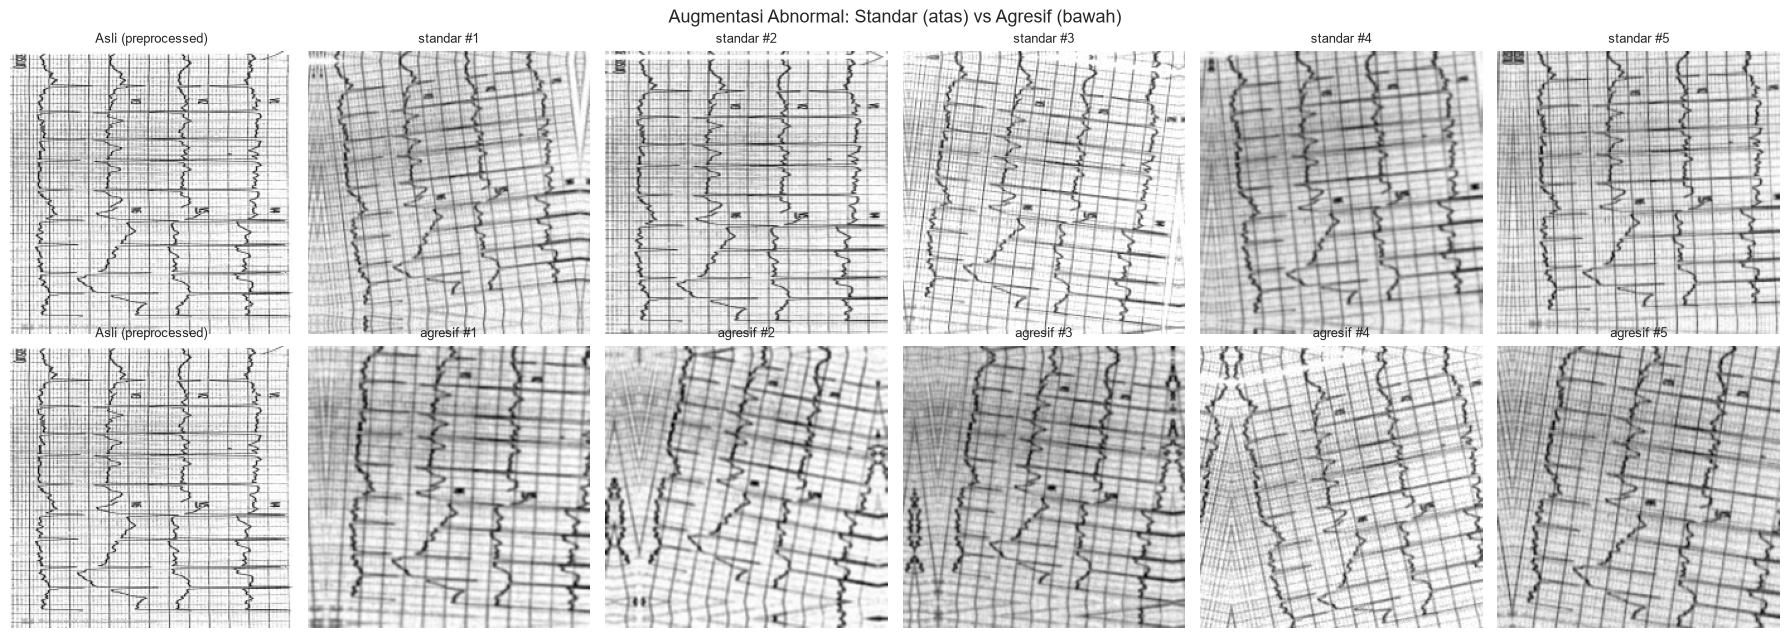

In [29]:
# --- Bandingkan augmentasi standar vs agresif pada 1 gambar Abnormal ---
np.random.seed(SEED)
ab_idx = np.where(all_labels_arr == "Abnormal")[0][0]
base_img = cached_images[ab_idx]
n_var = 5

fig, axes = plt.subplots(2, n_var + 1, figsize=(3 * (n_var + 1), 6.5))
axes[0, 0].imshow(base_img, cmap="gray"); axes[0, 0].set_title("Asli (preprocessed)", fontsize=9); axes[0, 0].axis("off")
axes[1, 0].imshow(base_img, cmap="gray"); axes[1, 0].set_title("Asli (preprocessed)", fontsize=9); axes[1, 0].axis("off")

for v in range(n_var):
    std_img = augment_image(base_img, "Abnormal")                                   # 1.5x standar
    agg_img = augment_with(base_img, "Abnormal", AGGRESSIVE_MULTIPLIER, AGGRESSIVE_BASE_APPLY_PROB)  # 2.5x agresif
    axes[0, v + 1].imshow(std_img, cmap="gray"); axes[0, v + 1].set_title(f"standar #{v+1}", fontsize=9); axes[0, v + 1].axis("off")
    axes[1, v + 1].imshow(agg_img, cmap="gray"); axes[1, v + 1].set_title(f"agresif #{v+1}", fontsize=9); axes[1, v + 1].axis("off")

axes[0, 0].set_ylabel("STANDAR 1.5x", fontsize=10)
axes[1, 0].set_ylabel("AGRESIF 2.5x", fontsize=10)
plt.suptitle("Augmentasi Abnormal: Standar (atas) vs Agresif (bawah)", fontsize=13)
plt.tight_layout()
plt.show()


## 13. Training Loop Versi Oversampled

`run_cv_oversampled` memakai ulang `train_one_fold` dari Bagian II. Perbedaan: (a) fold training di-oversample seimbang, (b) augmentasi agresif untuk Abnormal, (c) loss tanpa class-weight (bobot 1:1), (d) fold test tetap murni.

In [30]:
class EKGOversampledDataset(Dataset):
    """Seperti EKGModelDataset, tapi mendukung augmentasi agresif untuk data oversampled."""

    def __init__(self, indices, augment: bool = False, aggressive: bool = False):
        self.indices = np.asarray(indices)
        self.augment = augment
        self.aggressive = aggressive

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        idx = self.indices[i]
        img = cached_images[idx]
        label_name = all_labels_arr[idx]
        if self.augment:
            if self.aggressive:
                img = augment_with(img, label_name, AGGRESSIVE_MULTIPLIER, AGGRESSIVE_BASE_APPLY_PROB)
            else:
                img = augment_image(img, label_name)
        img_3ch = np.repeat(img[np.newaxis, :, :], 3, axis=0)
        img_3ch = (img_3ch - IMAGENET_MEAN) / IMAGENET_STD
        return torch.from_numpy(img_3ch).float(), LABEL_TO_IDX[label_name]


def run_cv_oversampled(model_builder, model_name: str):
    """5-fold CV dengan oversampling + augmentasi agresif + loss tanpa class-weight."""
    fold_metrics, fold_histories = [], []
    labels_cv, preds_cv, probs_cv = [], [], []
    equal_weights = torch.tensor([1.0, 1.0], dtype=torch.float32)  # data sudah seimbang

    for fold, (train_idx, test_idx) in enumerate(fold_indices):
        print(f"\n=== {model_name} [OVERSAMPLED] | Fold {fold + 1}/{N_SPLITS} ===")
        torch.manual_seed(SEED + fold)

        train_bal = oversample_indices(train_idx, seed=SEED + fold)
        train_loader_fold = DataLoader(
            EKGOversampledDataset(train_bal, augment=True, aggressive=True),
            batch_size=BATCH_SIZE_MODEL, shuffle=True, num_workers=0,
        )
        test_loader_fold = DataLoader(
            EKGOversampledDataset(test_idx, augment=False, aggressive=False),
            batch_size=BATCH_SIZE_MODEL, shuffle=False, num_workers=0,
        )

        model = model_builder()
        history, y_true, y_pred, y_prob = train_one_fold(model, train_loader_fold, test_loader_fold, equal_weights)

        fold_histories.append(history)
        labels_cv.append(y_true); preds_cv.append(y_pred); probs_cv.append(y_prob)

        acc = accuracy_score(y_true, y_pred)
        prec = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
        rec = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
        f1 = f1_score(y_true, y_pred, pos_label=1, zero_division=0)
        auc = roc_auc_score(y_true, y_prob)
        fold_metrics.append({"fold": fold + 1, "accuracy": acc, "precision": prec,
                              "recall": rec, "f1": f1, "auc": auc})
        print(f"  acc={acc:.3f}  precision={prec:.3f}  recall={rec:.3f}  f1={f1:.3f}  auc={auc:.3f}")

        del model
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    return pd.DataFrame(fold_metrics), fold_histories, labels_cv, preds_cv, probs_cv


print("run_cv_oversampled siap.")


run_cv_oversampled siap.


In [31]:
t0 = time.time()
cnn_os_metrics_df, cnn_os_histories, cnn_os_labels_cv, cnn_os_preds_cv, cnn_os_probs_cv = run_cv_oversampled(
    build_cnn_baseline, "CNN Baseline"
)
print(f"\nCNN Baseline [oversampled] selesai dalam {time.time()-t0:.1f} detik")
cnn_os_metrics_df



=== CNN Baseline [OVERSAMPLED] | Fold 1/5 ===


  acc=0.664  precision=1.000  recall=0.049  f1=0.093  auc=0.796

=== CNN Baseline [OVERSAMPLED] | Fold 2/5 ===


  acc=0.655  precision=1.000  recall=0.024  f1=0.048  auc=0.691

=== CNN Baseline [OVERSAMPLED] | Fold 3/5 ===


  acc=0.672  precision=0.800  recall=0.098  f1=0.174  auc=0.796

=== CNN Baseline [OVERSAMPLED] | Fold 4/5 ===


  acc=0.655  precision=0.600  recall=0.073  f1=0.130  auc=0.794

=== CNN Baseline [OVERSAMPLED] | Fold 5/5 ===


  acc=0.698  precision=0.857  recall=0.150  f1=0.255  auc=0.774

CNN Baseline [oversampled] selesai dalam 142.1 detik


,fold,accuracy,precision,recall,f1,auc
0,1,0.663793,1.000000,0.048780,0.093023,0.796098
1,2,0.655172,1.000000,0.024390,0.047619,0.691382
2,3,0.672414,0.800000,0.097561,0.173913,0.796098
3,4,0.655172,0.600000,0.073171,0.130435,0.793821
4,5,0.698276,0.857143,0.150000,0.255319,0.773684


In [32]:
t0 = time.time()
hybrid_os_metrics_df, hybrid_os_histories, hybrid_os_labels_cv, hybrid_os_preds_cv, hybrid_os_probs_cv = run_cv_oversampled(
    lambda: CNNTransformerHybrid(), "CNN+Transformer Hybrid"
)
print(f"\nHybrid [oversampled] selesai dalam {time.time()-t0:.1f} detik")
hybrid_os_metrics_df



=== CNN+Transformer Hybrid [OVERSAMPLED] | Fold 1/5 ===


  acc=0.647  precision=0.000  recall=0.000  f1=0.000  auc=0.732

=== CNN+Transformer Hybrid [OVERSAMPLED] | Fold 2/5 ===


  acc=0.698  precision=0.667  recall=0.293  f1=0.407  auc=0.776

=== CNN+Transformer Hybrid [OVERSAMPLED] | Fold 3/5 ===


  acc=0.690  precision=1.000  recall=0.122  f1=0.217  auc=0.850

=== CNN+Transformer Hybrid [OVERSAMPLED] | Fold 4/5 ===


  acc=0.707  precision=0.818  recall=0.220  f1=0.346  auc=0.830

=== CNN+Transformer Hybrid [OVERSAMPLED] | Fold 5/5 ===


  acc=0.681  precision=0.800  recall=0.100  f1=0.178  auc=0.725

Hybrid [oversampled] selesai dalam 163.5 detik


,fold,accuracy,precision,recall,f1,auc
0,1,0.646552,0.000000,0.000000,0.000000,0.732033
1,2,0.698276,0.666667,0.292683,0.406780,0.775610
2,3,0.689655,1.000000,0.121951,0.217391,0.850081
3,4,0.706897,0.818182,0.219512,0.346154,0.829593
4,5,0.681034,0.800000,0.100000,0.177778,0.724671


## 14. Analisis Perbandingan: Class-Weight (Bagian II) vs Oversampling+Augmentasi Agresif

Fokus utama: apakah **recall Abnormal** naik? Dan berapa harga yang dibayar di precision?

In [33]:
# --- Tabel banding 4 kondisi ---
conditions = [
    ("CNN | ClassWeight (baseline)", cnn_metrics_df),
    ("CNN | Oversample+AggAug",      cnn_os_metrics_df),
    ("Hybrid | ClassWeight (baseline)", hybrid_metrics_df),
    ("Hybrid | Oversample+AggAug",      hybrid_os_metrics_df),
]
rows = []
for name, dfm in conditions:
    row = {"kondisi": name}
    for c in METRIC_COLS:
        row[c] = f"{dfm[c].mean():.3f} ± {dfm[c].std():.3f}"
    rows.append(row)
compare_os_df = pd.DataFrame(rows).set_index("kondisi")
print("Perbandingan mean ± std (5-fold):")
compare_os_df


Perbandingan mean ± std (5-fold):


,accuracy,precision,recall,f1,auc
kondisi,,,,,
CNN | ClassWeight (baseline),0.841 ± 0.028,0.956 ± 0.035,0.578 ± 0.097,0.715 ± 0.069,0.870 ± 0.030
CNN | Oversample+AggAug,0.669 ± 0.018,0.851 ± 0.166,0.079 ± 0.048,0.140 ± 0.080,0.770 ± 0.045
Hybrid | ClassWeight (baseline),0.845 ± 0.033,0.893 ± 0.060,0.637 ± 0.087,0.740 ± 0.066,0.893 ± 0.039
Hybrid | Oversample+AggAug,0.684 ± 0.023,0.657 ± 0.386,0.147 ± 0.113,0.230 ± 0.159,0.782 ± 0.056


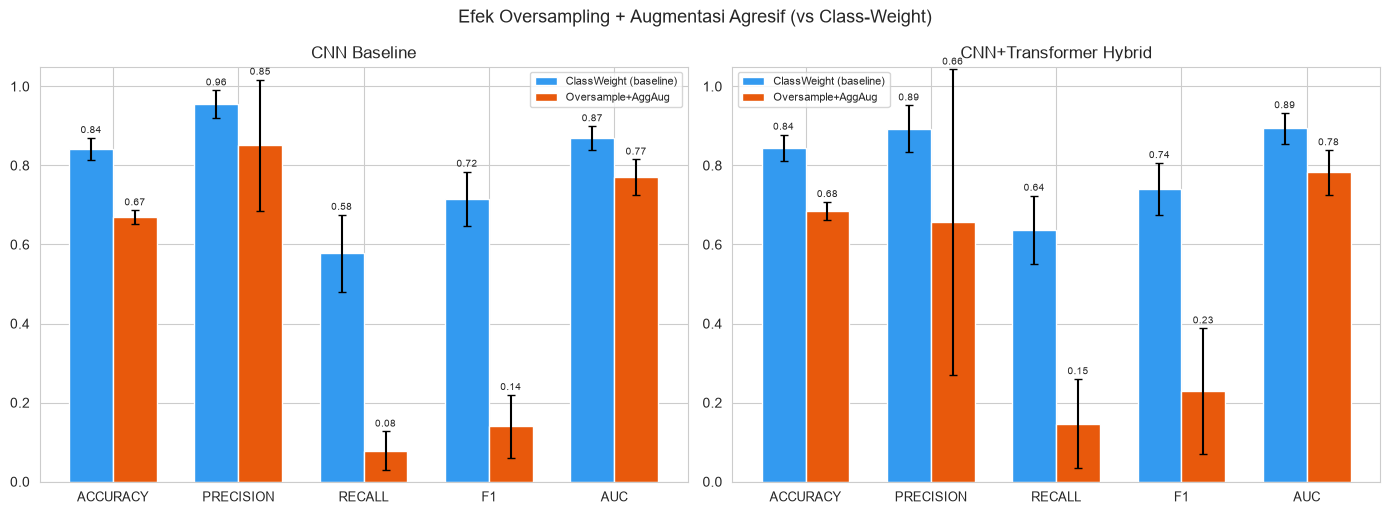

In [34]:
# --- Grafik: efek oversampling per model (baseline vs oversampled) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))
x = np.arange(len(METRIC_COLS)); width = 0.35

for ax, (title, base_df, os_df) in zip(axes, [
    ("CNN Baseline", cnn_metrics_df, cnn_os_metrics_df),
    ("CNN+Transformer Hybrid", hybrid_metrics_df, hybrid_os_metrics_df),
]):
    base_means = [base_df[c].mean() for c in METRIC_COLS]
    os_means = [os_df[c].mean() for c in METRIC_COLS]
    base_stds = [base_df[c].std() for c in METRIC_COLS]
    os_stds = [os_df[c].std() for c in METRIC_COLS]
    b1 = ax.bar(x - width/2, base_means, width, yerr=base_stds, capsize=3, label="ClassWeight (baseline)", color="#339af0")
    b2 = ax.bar(x + width/2, os_means, width, yerr=os_stds, capsize=3, label="Oversample+AggAug", color="#e8590c")
    ax.set_xticks(x); ax.set_xticklabels([c.upper() for c in METRIC_COLS], fontsize=9)
    ax.set_ylim(0, 1.05); ax.set_title(title); ax.legend(fontsize=8)
    ax.bar_label(b1, fmt="%.2f", padding=2, fontsize=7)
    ax.bar_label(b2, fmt="%.2f", padding=2, fontsize=7)

plt.suptitle("Efek Oversampling + Augmentasi Agresif (vs Class-Weight)", fontsize=13)
plt.tight_layout()
plt.show()


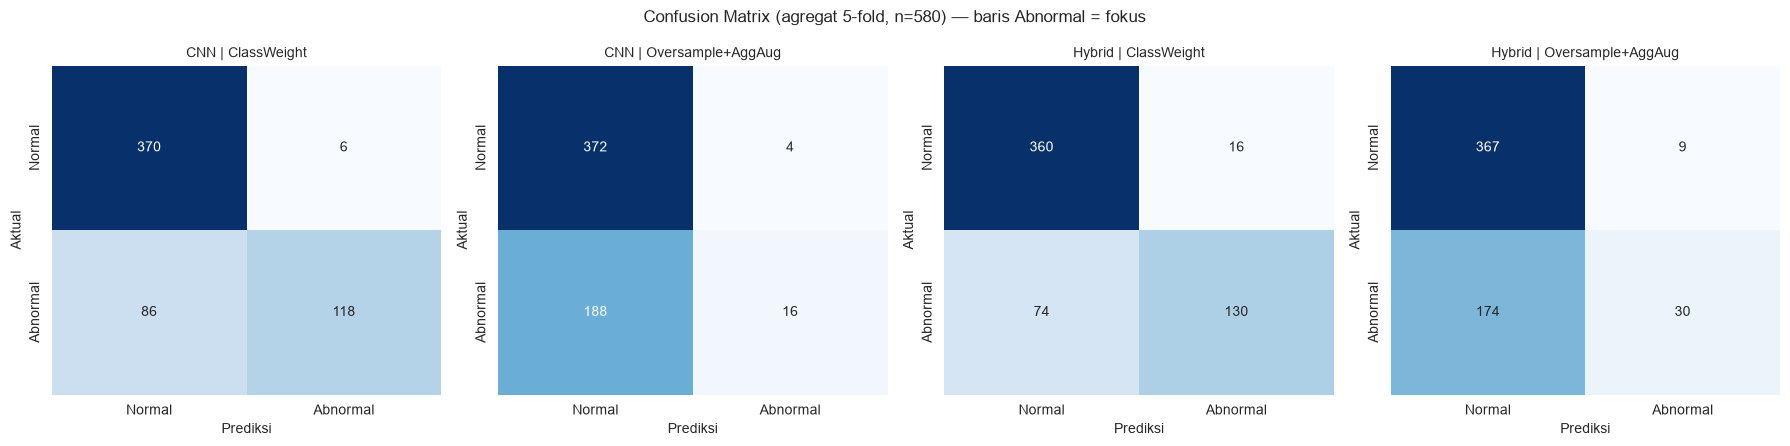

CNN | ClassWeight                | Abnormal terdeteksi(TP)=118  terlewat(FN)= 86  |  Normal salah-alarm(FP)=  6
CNN | Oversample+AggAug          | Abnormal terdeteksi(TP)= 16  terlewat(FN)=188  |  Normal salah-alarm(FP)=  4
Hybrid | ClassWeight             | Abnormal terdeteksi(TP)=130  terlewat(FN)= 74  |  Normal salah-alarm(FP)= 16
Hybrid | Oversample+AggAug       | Abnormal terdeteksi(TP)= 30  terlewat(FN)=174  |  Normal salah-alarm(FP)=  9


In [35]:
# --- Confusion matrix: baseline vs oversampled, untuk kedua model (agregat 5-fold) ---
def agg_cm(labels_cv, preds_cv):
    return confusion_matrix(np.concatenate(labels_cv), np.concatenate(preds_cv))

cms = [
    ("CNN | ClassWeight", agg_cm(cnn_labels_cv, cnn_preds_cv)),
    ("CNN | Oversample+AggAug", agg_cm(cnn_os_labels_cv, cnn_os_preds_cv)),
    ("Hybrid | ClassWeight", agg_cm(hybrid_labels_cv, hybrid_preds_cv)),
    ("Hybrid | Oversample+AggAug", agg_cm(hybrid_os_labels_cv, hybrid_os_preds_cv)),
]
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
for ax, (title, cm) in zip(axes, cms):
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_xlabel("Prediksi"); ax.set_ylabel("Aktual"); ax.set_title(title, fontsize=10)
plt.suptitle("Confusion Matrix (agregat 5-fold, n=580) — baris Abnormal = fokus", fontsize=12)
plt.tight_layout()
plt.show()

for title, cm in cms:
    tn, fp, fn, tp = cm.ravel()
    print(f"{title:32s} | Abnormal terdeteksi(TP)={tp:3d}  terlewat(FN)={fn:3d}  |  Normal salah-alarm(FP)={fp:3d}")


In [36]:
# --- Kesimpulan otomatis: efek oversampling ---
def recall_mean(dfm): return dfm["recall"].mean()
def prec_mean(dfm): return dfm["precision"].mean()
def f1_mean(dfm): return dfm["f1"].mean()
def auc_mean(dfm): return dfm["auc"].mean()

print("=" * 72)
print("KESIMPULAN OTOMATIS — Efek Oversampling + Augmentasi Agresif")
print("=" * 72)
for mname, base_df, os_df in [
    ("CNN Baseline", cnn_metrics_df, cnn_os_metrics_df),
    ("CNN+Transformer Hybrid", hybrid_metrics_df, hybrid_os_metrics_df),
]:
    d_rec = recall_mean(os_df) - recall_mean(base_df)
    d_prec = prec_mean(os_df) - prec_mean(base_df)
    d_f1 = f1_mean(os_df) - f1_mean(base_df)
    d_auc = auc_mean(os_df) - auc_mean(base_df)
    print(f"\n[{mname}]")
    print(f"  Recall Abnormal : {recall_mean(base_df):.3f} -> {recall_mean(os_df):.3f}  ({d_rec:+.3f})")
    print(f"  Precision       : {prec_mean(base_df):.3f} -> {prec_mean(os_df):.3f}  ({d_prec:+.3f})")
    print(f"  F1 Abnormal     : {f1_mean(base_df):.3f} -> {f1_mean(os_df):.3f}  ({d_f1:+.3f})")
    print(f"  AUC             : {auc_mean(base_df):.3f} -> {auc_mean(os_df):.3f}  ({d_auc:+.3f})")
    verdict = "MEMBANTU" if d_rec > 0.01 else ("NETRAL" if abs(d_rec) <= 0.01 else "MENURUNKAN")
    print(f"  -> Untuk recall Abnormal, oversampling {verdict} (delta recall {d_rec:+.3f})")

print("\n" + "=" * 72)
print("""CATATAN:
- Jika recall NAIK tapi precision TURUN: itu trade-off yang diharapkan. Lihat F1
  untuk menilai apakah keseimbangannya membaik secara keseluruhan.
- Jika recall TIDAK bergerak: model tidak 'haus' eksposur Abnormal tambahan;
  bottleneck-nya kemungkinan besar kualitas/keragaman data, bukan kuantitas.
  Ini sinyal bahwa GAN/data sintetis mahal pun kemungkinan tidak menolong.
- Data test tiap fold 100% asli (tidak di-oversample) sehingga metrik ini jujur.""")


KESIMPULAN OTOMATIS — Efek Oversampling + Augmentasi Agresif

[CNN Baseline]
  Recall Abnormal : 0.578 -> 0.079  (-0.499)
  Precision       : 0.956 -> 0.851  (-0.104)
  F1 Abnormal     : 0.715 -> 0.140  (-0.575)
  AUC             : 0.870 -> 0.770  (-0.100)
  -> Untuk recall Abnormal, oversampling MENURUNKAN (delta recall -0.499)

[CNN+Transformer Hybrid]
  Recall Abnormal : 0.637 -> 0.147  (-0.490)
  Precision       : 0.893 -> 0.657  (-0.236)
  F1 Abnormal     : 0.740 -> 0.230  (-0.511)
  AUC             : 0.893 -> 0.782  (-0.111)
  -> Untuk recall Abnormal, oversampling MENURUNKAN (delta recall -0.490)

CATATAN:
- Jika recall NAIK tapi precision TURUN: itu trade-off yang diharapkan. Lihat F1
  untuk menilai apakah keseimbangannya membaik secara keseluruhan.
- Jika recall TIDAK bergerak: model tidak 'haus' eksposur Abnormal tambahan;
  bottleneck-nya kemungkinan besar kualitas/keragaman data, bukan kuantitas.
  Ini sinyal bahwa GAN/data sintetis mahal pun kemungkinan tidak menolong.
- 